In [1]:
import numpy as np

# Define dimensions
num_channels = 4  # Channels: 1, 2, 3, 4 (indices 0-3)
value_range = (0, 10)  # Values: 0 to 10 (11 values, indices 0-10)
z_range = (0, 11)  # z: 0 to 11 (12 values, indices 0-11)
y_range = (0, 86)  # y: 0 to 86 (87 values, indices 0-86)
x_range = (0, 171)  # x: 0 to 171 (172 values, indices 0-171)

# Calculate array dimensions
num_values = value_range[1] - value_range[0] + 1  # 11 values (0-10)
z_dim = z_range[1] - z_range[0] + 1  # 12 values (0-11)
y_dim = y_range[1] - y_range[0] + 1  # 87 values (0-86)
x_dim = x_range[1] - x_range[0] + 1  # 172 values (0-171)

# Create 5D array initialized with zeros
# Shape: (channel, value, z, y, x)
data = np.zeros((num_channels, num_values, z_dim, y_dim, x_dim), dtype=np.int8)

# Generate random values for each (z, y, x) position
for i in range(0, 3):
    for z in range(z_dim):
        # Channel 0: x ranges 38+40*i to 43+40*i, for all y
        for y in range(y_dim):
            x_start = max(0, 38+20*i)
            x_end = min(x_dim, 43+20*i)
            for x in range(x_start, x_end):
                random_value = np.random.randint(6, 11)
                data[0, random_value, z, y, x] = 1
        # Channel 1: y ranges 18+20*i to 23+20*i, for all x
        y_start = max(0, 18+20*i)
        y_end = min(y_dim, 23+20*i)
        for y in range(y_start, y_end):
            for x in range(x_dim):
                random_value = np.random.randint(6, 11)
                data[1, random_value, z, y, x] = 1
        # Channel 2: 1 diagonal lines with slope 1 (y = x + c)
        strip_width = 3  # Narrower width for diagonal strips
        c_values = [-60, 0]  # 3 lines: y=x-60, y=x, y=x+60
        for c in c_values:
            for y in range(y_dim):
                for x in range(x_dim):
                    if abs(y - x - c) <= strip_width:
                        random_value = np.random.randint(6, 11)
                        data[2, random_value, z, y, x] = 1
        # Channel 3: 1 diagonal lines with slope -1 (y = -x + d)
        strip_width = 3  # Narrower width for diagonal strips
        d_values = [60, 120]  # 3 lines: y=-x+60, y=-x+120, y=-x+180
        for d in d_values:
            for y in range(y_dim):
                for x in range(x_dim):
                    if abs(y + x - d) <= strip_width:
                        random_value = np.random.randint(6, 11)
                        data[3, random_value, z, y, x] = 1

print(f"Created 5D data array with shape: {data.shape}")
print(f"Dimensions breakdown:")
print(f"  - Channels: {num_channels} (1, 2, 3, 4)")
print(f"  - Values: {num_values} (0 to {value_range[1]})")
print(f"  - Z: {z_dim} (0 to {z_range[1]})")
print(f"  - Y: {y_dim} (0 to {y_range[1]})")
print(f"  - X: {x_dim} (0 to {x_range[1]})")
print(f"\nData type: {data.dtype}")
print(f"Total elements: {data.size:,}")
print(f"Memory size: {data.nbytes / 1024 / 1024:.2f} MB")

# Save the data
np.save('groundtruth.npy', data)
print(f"\n✓ 5D data saved to: groundtruth.npy")


Created 5D data array with shape: (4, 11, 12, 87, 172)
Dimensions breakdown:
  - Channels: 4 (1, 2, 3, 4)
  - Values: 11 (0 to 10)
  - Z: 12 (0 to 11)
  - Y: 87 (0 to 86)
  - X: 172 (0 to 171)

Data type: int8
Total elements: 7,900,992
Memory size: 7.53 MB

✓ 5D data saved to: groundtruth.npy


C:\Users\Hossein\AppData\Local\Temp\ipykernel_9592\1887135946.py:12: RuntimeWarning:

invalid value encountered in divide



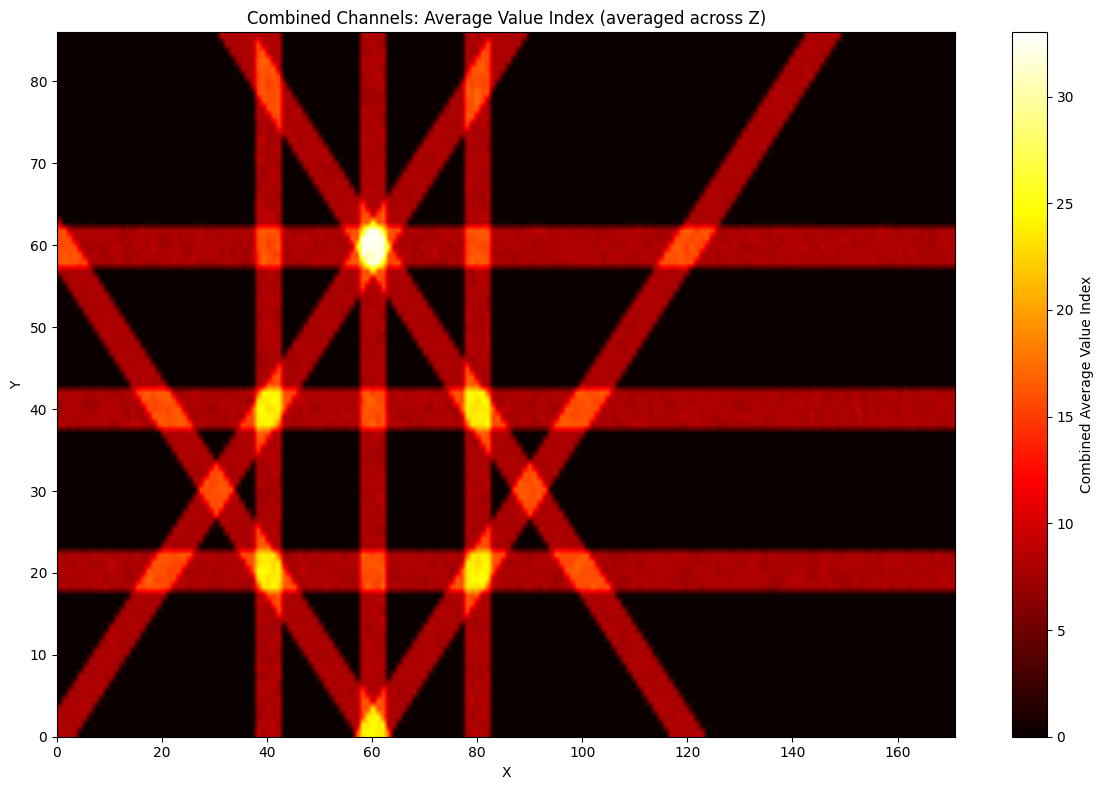


✓ Combined channels visualization
  Image shape: (87, 172)
  Value range: [0.00, 33.01]


In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Load data
data = np.load('groundtruth.npy')
combined_image = np.zeros((y_dim, x_dim), dtype=np.float32)
for channel in range(4):
    channel_data = data[channel]  # Shape: (11, 12, 87, 172)
    value_indices = np.arange(11).reshape(-1, 1, 1, 1)  # Shape: (11, 1, 1, 1)
    weighted_sum = np.sum(value_indices * channel_data, axis=0)  # Shape: (12, 87, 172)
    total_sum = np.sum(channel_data, axis=0)  # Shape: (12, 87, 172)
    avg_value_index = np.where(total_sum > 0, weighted_sum / total_sum, 0)  # Shape: (12, 87, 172)
    avg_z = np.mean(avg_value_index, axis=0)  # Shape: (87, 172)
    combined_image += avg_z
# Plot combined image
plt.figure(figsize=(12, 8))
plt.imshow(combined_image, origin='lower', extent=[0, x_dim-1, 0, y_dim-1],
           aspect='auto', interpolation='bilinear', cmap='hot')
plt.colorbar(label='Combined Average Value Index')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Combined Channels: Average Value Index (averaged across Z)')
plt.xlim(0, x_dim-1)
plt.ylim(0, y_dim-1)
plt.tight_layout()
plt.show()

print(f"\n✓ Combined channels visualization")
print(f"  Image shape: {combined_image.shape}")
print(f"  Value range: [{combined_image.min():.2f}, {combined_image.max():.2f}]")


C:\Users\Hossein\AppData\Local\Temp\ipykernel_9592\1277307529.py:29: RuntimeWarning:

invalid value encountered in divide



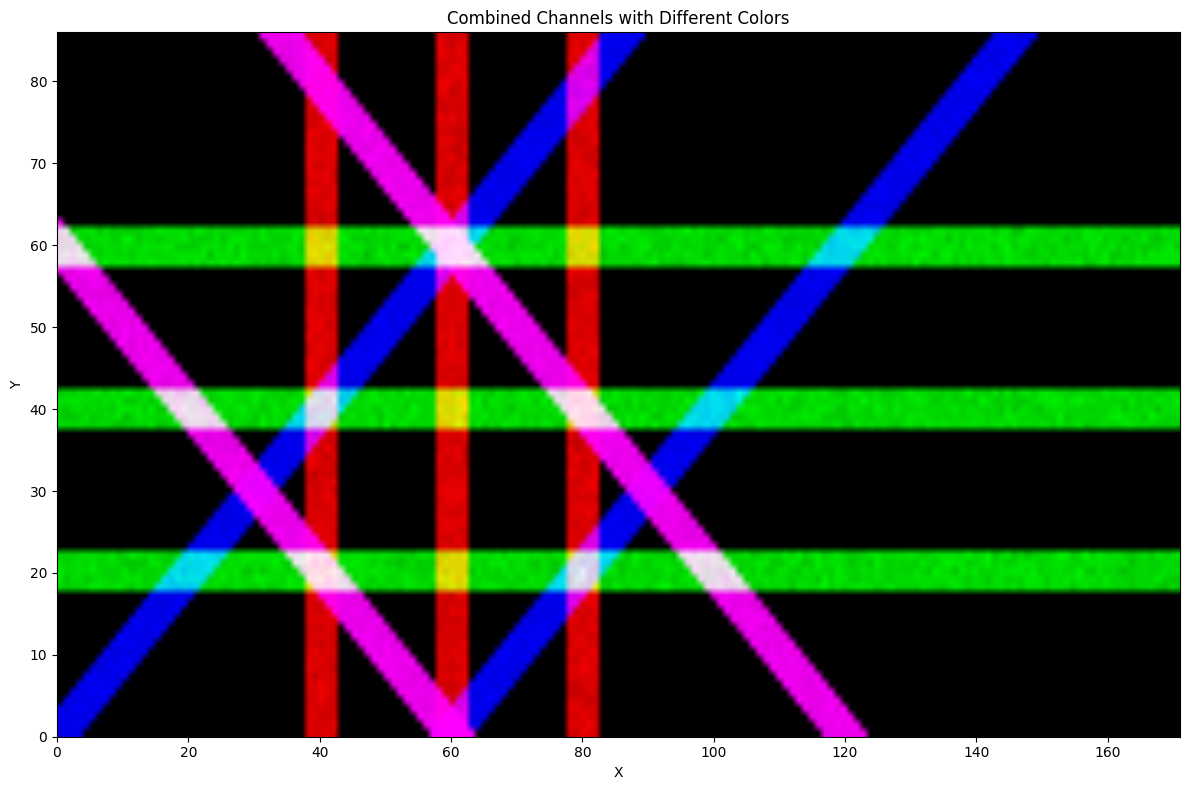


✓ Combined channels visualization (RGB)
  RGB image shape: (87, 172, 3)
  Per-channel image shape: (4, 87, 172)


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Load data: shape (channel, value, z, y, x)
data = np.load('groundtruth.npy')
n_channels, n_values, n_z, y_dim, x_dim = data.shape

# Predefine an RGB color for each channel (R, G, B)
channel_colors = np.array([
    [1.0, 0.0, 0.0],  # Channel 0: red
    [0.0, 1.0, 0.0],  # Channel 1: green
    [0.0, 0.0, 1.0],  # Channel 2: blue
    [1.0, 0.0, 1.0],  # Channel 3: magenta
], dtype=np.float32)

# Store the 2D projection per channel
per_channel_2d = np.zeros((n_channels, y_dim, x_dim), dtype=np.float32)

for channel in range(n_channels):
    channel_data = data[channel]  # Shape: (value, z, y, x) = (11, 12, 87, 172)

    # value indices: 0..(n_values-1)
    value_indices = np.arange(n_values).reshape(-1, 1, 1, 1)  # (value, 1, 1, 1)

    # Weighted sum over "value" axis
    weighted_sum = np.sum(value_indices * channel_data, axis=0)  # (z, y, x)
    total_sum = np.sum(channel_data, axis=0)                     # (z, y, x)

    avg_value_index = np.where(total_sum > 0, weighted_sum / total_sum, 0)  # (z, y, x)

    # Average over z to get a 2D image for this channel
    avg_z = np.mean(avg_value_index, axis=0)  # (y, x)

    per_channel_2d[channel] = avg_z

# Build an RGB image from all channels
combined_rgb = np.zeros((y_dim, x_dim, 3), dtype=np.float32)

for channel in range(n_channels):
    img = per_channel_2d[channel]

    # Skip empty channels
    if np.all(img == 0):
        continue

    # Normalize this channel's image to [0, 1] for visualization
    img_min = img.min()
    img_max = img.max()
    norm = (img - img_min) / (img_max - img_min + 1e-6)

    # Add this channel's contribution in its own color
    color = channel_colors[channel]  # (3,)
    combined_rgb += norm[..., None] * color  # broadcast to (y, x, 3)

# Clip to valid [0, 1] RGB range
combined_rgb = np.clip(combined_rgb, 0.0, 1.0)

# Plot combined RGB image
plt.figure(figsize=(12, 8))
plt.imshow(
    combined_rgb,
    origin='lower',
    extent=[0, x_dim - 1, 0, y_dim - 1],
    aspect='auto',
    interpolation='bilinear'
)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Combined Channels with Different Colors')
plt.xlim(0, x_dim - 1)
plt.ylim(0, y_dim - 1)
plt.tight_layout()
plt.show()

print("\n✓ Combined channels visualization (RGB)")
print(f"  RGB image shape: {combined_rgb.shape}")
print(f"  Per-channel image shape: {per_channel_2d.shape}")


In [39]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio


pio.renderers.default = "browser"
# Load data: shape (channel, value, z, y, x)
data = np.load("groundtruth.npy")
n_channels, n_values, n_z, y_dim, x_dim = data.shape

# Colors per channel
channel_colors = [
    "red",      # channel 0
    "green",    # channel 1
    "blue",     # channel 2
    "magenta",  # channel 3
]

# Compute a 3D scalar field per channel: avg over "value"
per_channel_3d = np.zeros((n_channels, n_z, y_dim, x_dim), dtype=np.float32)

for ch in range(n_channels):
    channel_data = data[ch]

    value_indices = np.arange(n_values, dtype=np.float32).reshape(-1, 1, 1, 1)
    weighted_sum = np.sum(value_indices * channel_data, axis=0)
    total_sum = np.sum(channel_data, axis=0)

    avg_value_index = np.zeros_like(weighted_sum)
    mask = total_sum > 0
    avg_value_index[mask] = weighted_sum[mask] / total_sum[mask]

    per_channel_3d[ch] = avg_value_index


# --- Plotly 3D scatter ---
fig = go.Figure()
threshold = 0.5
max_points = 2000000

for ch in range(n_channels):
    vol = per_channel_3d[ch]

    if np.all(vol == 0):
        continue

    vmin, vmax = vol.min(), vol.max()
    if vmax <= vmin:
        continue

    norm = (vol - vmin) / (vmax - vmin + 1e-6)
    mask = norm > threshold

    if not np.any(mask):
        continue

    z_idx, y_idx, x_idx = np.where(mask)

    # limit number of points
    n_pts = len(x_idx)
    if n_pts > max_points:
        selected = np.random.choice(n_pts, max_points, replace=False)
        x_idx = x_idx[selected]
        y_idx = y_idx[selected]
        z_idx = z_idx[selected]

    fig.add_trace(go.Scatter3d(
        x=x_idx,
        y=y_idx,
        z=z_idx,
        mode="markers",
        marker=dict(
            size=2,
            color=channel_colors[ch],
            opacity=0.4  # must be single number!
        ),
        name=f"Channel {ch}"
    ))


fig.update_layout(
    title="3D Interactive View of Channels",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data",
    ),
    width=900,
    height=700,
    showlegend=True,
)

fig.show()


In [13]:
import numpy as np

# Load groundtruth data
data = np.load('groundtruth.npy')
print(f"Data shape: {data.shape}")

# Extract data for z=1 (z index 1)
z_index = 5
z_data = data[:, :, z_index, :, :]  # Shape: (4, 11, 87, 172) - all channels, all values, z=1, all y, all x

# For each (x, y) coordinate, check which channels have non-zero values
# Sum across value dimension to check if channel has any non-zero value
channel_sums = np.sum(z_data, axis=1)  # Shape: (4, 87, 172) - sum across value dimension
channel_has_data = (channel_sums > 0).astype(int)  # Shape: (4, 87, 172) - 1 if channel has data, 0 otherwise

# Count number of channels with non-zero values for each (x, y) coordinate
num_channels_per_coord = np.sum(channel_has_data, axis=0)  # Shape: (87, 172)

# Count how many coordinates have 1, 2, 3, or 4 channels
count_1_channel = np.sum(num_channels_per_coord == 1)
count_2_channels = np.sum(num_channels_per_coord == 2)
count_3_channels = np.sum(num_channels_per_coord == 3)
count_4_channels = np.sum(num_channels_per_coord == 4)

# Find coordinates with 4 channels
y_indices, x_indices = np.where(num_channels_per_coord == 4)
coordinates_4_channels = list(zip(x_indices, y_indices))

# Print results
print(f"\nAnalysis for z={z_index}:")
print(f"=" * 50)
print(f"Coordinates with 1 channel:  {count_1_channel:,}")
print(f"Coordinates with 2 channels: {count_2_channels:,}")
print(f"Coordinates with 3 channels: {count_3_channels:,}")
print(f"Coordinates with 4 channels: {count_4_channels:,}")
print(f"=" * 50)
print(f"Total coordinates analyzed: {num_channels_per_coord.size:,}")
print(f"  (Y dimension: {y_dim}, X dimension: {x_dim})")

# Print coordinates with 4 channels
if count_4_channels > 0:
    print(f"\nCoordinates with 4 channels:")
    for x, y in coordinates_4_channels:
        print(f"  x,y: {x},{y}")
else:
    print(f"\nNo coordinates found with 4 channels.")


Data shape: (4, 11, 12, 87, 172)

Analysis for z=5:
Coordinates with 1 channel:  4,561
Coordinates with 2 channels: 573
Coordinates with 3 channels: 114
Coordinates with 4 channels: 21
Total coordinates analyzed: 14,964
  (Y dimension: 87, X dimension: 172)

Coordinates with 4 channels:
  x,y: 59,58
  x,y: 60,58
  x,y: 61,58
  x,y: 58,59
  x,y: 59,59
  x,y: 60,59
  x,y: 61,59
  x,y: 62,59
  x,y: 58,60
  x,y: 59,60
  x,y: 60,60
  x,y: 61,60
  x,y: 62,60
  x,y: 58,61
  x,y: 59,61
  x,y: 60,61
  x,y: 61,61
  x,y: 62,61
  x,y: 59,62
  x,y: 60,62
  x,y: 61,62


#Create graphs and subgraphs

In [14]:
import numpy as np
from torch_geometric.data import Data
import torch
import os
import time

# Function to calculate 3D Euclidean distance
def calculate_distance(x1, y1, z1, x2, y2, z2):
    """Calculate 3D Euclidean distance between two points"""
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2)

# Load groundtruth data
print("Loading groundtruth data...")
data = np.load('groundtruth.npy')
print(f"✓ Data loaded with shape: {data.shape}")

# Parameters
z_fixed = 5  # Fixed z coordinate (changed from 5 to 1 to match cell 19 analysis)
max_radius = 10  # Maximum radius for graph edges
step_size = 5  # Step size for graph centers

# Get dimensions
num_channels, num_values, z_dim, y_dim, x_dim = data.shape
print(f"Dimensions: channels={num_channels}, values={num_values}, z={z_dim}, y={y_dim}, x={x_dim}")

# Extract data for z=1 only
z_idx = z_fixed
print(f"\nExtracting data for z={z_fixed} (index {z_idx})...")

# Pre-compute intensity matrix for z=1
print("Pre-computing intensity matrix for z=1...")
start_time = time.time()
intensity_matrix = np.zeros((y_dim, x_dim, num_channels), dtype=np.float32)
channel_mask = np.zeros((y_dim, x_dim, num_channels), dtype=bool)

for channel in range(num_channels):
    channel_data = data[channel, :, z_idx, :, :]  # Shape: (num_values, y_dim, x_dim)
    # Find value indices where channel_data[value_idx, y, x] = 1
    value_indices = np.argmax(channel_data, axis=0)  # Shape: (y_dim, x_dim)
    # Check if any value is set
    mask = channel_data.sum(axis=0) > 0  # Shape: (y_dim, x_dim)
    intensity_matrix[:, :, channel] = np.where(mask, value_indices.astype(np.float32), 0.0)
    channel_mask[:, :, channel] = mask

elapsed = time.time() - start_time
print(f"✓ Intensity matrix computed in {elapsed:.2f} seconds")

# Count channels for each coordinate
print("\nCounting channels per coordinate...")
channel_counts = channel_mask.sum(axis=2)  # Shape: (y_dim, x_dim)
print(f"  Coordinates with 4 channels: {(channel_counts == 4).sum()}")
print(f"  Coordinates with 3 channels: {(channel_counts == 3).sum()}")
print(f"  Coordinates with 2 channels: {(channel_counts == 2).sum()}")
print(f"  Coordinates with 1 channel: {(channel_counts == 1).sum()}")
print(f"  Total non-zero coordinates: {(channel_counts > 0).sum()}")

# Generate graph centers with step_size=20
print(f"\nGenerating graph centers with step_size={step_size}...")
graph_centers = []
for x in range(0, x_dim, step_size):
    for y in range(0, y_dim, step_size):
        graph_centers.append((x, y, z_fixed))

print(f"Total graph centers: {len(graph_centers)}")

# Create subgraphs - one list for all graphs
print("\n" + "="*60)
print("Creating subgraphs...")
print("="*60)

all_subgraphs = []  # Single list for all subgraphs

graph_start_time = time.time()

for center_idx, (center_x, center_y, center_z) in enumerate(graph_centers):
    if center_idx % 5 == 0:
        print(f"Processing center {center_idx+1}/{len(graph_centers)}: ({center_x}, {center_y}, {center_z})")

    # Bounding box for optimization
    bounding_radius = max_radius
    x_min = max(0, int(center_x - bounding_radius))
    x_max = min(x_dim, int(center_x + bounding_radius) + 1)
    y_min = max(0, int(center_y - bounding_radius))
    y_max = min(y_dim, int(center_y + bounding_radius) + 1)

    # Find all coordinates within radius from center (all non-zero coordinates)
    nodes = []
    node_positions = []
    node_active_channels = []  # Store active channels for each node

    for y in range(y_min, y_max):
        for x in range(x_min, x_max):
            # Check if this coordinate has any channels
            if channel_counts[y, x] > 0:
                distance = calculate_distance(center_x, center_y, center_z, x, y, z_fixed)
                if distance <= max_radius:
                    # Get active channels for this coordinate
                    active_channels = np.where(channel_mask[y, x, :])[0].tolist()
                    # Extract intensities only for active channels
                    intensities = intensity_matrix[y, x, active_channels]  # Shape: (num_active_channels,)
                    nodes.append(intensities)
                    node_positions.append((x, y, z_fixed))
                    node_active_channels.append(active_channels)

    if len(nodes) == 0:
        continue

    # Find maximum number of channels across all nodes in this graph
    max_channels = max(len(channels) for channels in node_active_channels)

    # Pad node features to have same number of channels (use max_channels)
    # For nodes with fewer channels, pad with zeros
    padded_nodes = []
    for i, intensities in enumerate(nodes):
        active_ch = node_active_channels[i]
        num_ch = len(active_ch)
        if num_ch < max_channels:
            # Pad with zeros
            padded = np.zeros(max_channels, dtype=np.float32)
            padded[:num_ch] = intensities
            padded_nodes.append(padded)
        else:
            padded_nodes.append(intensities)

    # Convert to numpy array
    node_features = np.array(padded_nodes, dtype=np.float32)  # Shape: (num_nodes, max_channels)
    node_positions_array = np.array(node_positions, dtype=np.int32)  # Shape: (num_nodes, 3)
    num_nodes = len(nodes)

    # Subsample by factor 2
    subsample_factor = 1
    x_coords = node_positions_array[:, 0]
    y_coords = node_positions_array[:, 1]
    z_coords = node_positions_array[:, 2]

    x_min_coord = x_coords.min()
    y_min_coord = y_coords.min()
    z_min_coord = z_coords.min()

    mask = ((x_coords - x_min_coord) % subsample_factor == 0) & \
           ((y_coords - y_min_coord) % subsample_factor == 0) & \
           ((z_coords - z_min_coord) % subsample_factor == 0)

    node_features = node_features[mask]
    node_positions_array = node_positions_array[mask]
    node_active_channels = [node_active_channels[i] for i in range(len(mask)) if mask[i]]
    num_nodes = len(node_features)

    if num_nodes < 2:
        continue

    # Create edges
    node_positions_np = node_positions_array.astype(np.float32)

    if num_nodes < 5000:
        # Vectorized approach for small graphs
        diff = node_positions_np[:, np.newaxis, :] - node_positions_np[np.newaxis, :, :]
        distances_matrix = np.sqrt(np.sum(diff**2, axis=2))
        edge_mask = (distances_matrix <= max_radius) & (distances_matrix > 0)
        edge_i, edge_j = np.where(edge_mask)
        if len(edge_i) > 0:
            edge_weights_np = 1.0 / (1.0 + distances_matrix[edge_i, edge_j])
        else:
            continue
    else:
        # Memory-efficient approach for large graphs
        edge_i_list = []
        edge_j_list = []
        edge_weights_list = []
        for i in range(num_nodes):
            if i < num_nodes - 1:
                diff = node_positions_np[i+1:] - node_positions_np[i]
                distances = np.sqrt(np.sum(diff**2, axis=1))
                mask_edges = distances <= max_radius
                if np.any(mask_edges):
                    j_indices = np.where(mask_edges)[0] + i + 1
                    edge_i_list.extend([i] * len(j_indices))
                    edge_j_list.extend(j_indices.tolist())
                    edge_i_list.extend(j_indices.tolist())
                    edge_j_list.extend([i] * len(j_indices))
                    weights = 1.0 / (1.0 + distances[mask_edges])
                    edge_weights_list.extend(weights.tolist())
                    edge_weights_list.extend(weights.tolist())

        if len(edge_i_list) == 0:
            continue
        edge_i = np.array(edge_i_list)
        edge_j = np.array(edge_j_list)
        edge_weights_np = np.array(edge_weights_list)

    # Calculate node values (sum of intensities across all channels for each node)
    node_values = np.sum(node_features, axis=1)  # Shape: (num_nodes,)

    # Convert to PyTorch tensors
    edge_index = torch.tensor(np.stack([edge_i, edge_j]), dtype=torch.long)
    edge_attr = torch.tensor(edge_weights_np, dtype=torch.float32)
    x_tensor = torch.tensor(node_features, dtype=torch.float32)
    node_values_tensor = torch.tensor(node_values, dtype=torch.float32)

    # Create PyTorch Geometric Data object
    graph = Data(
        x=x_tensor,  # Node features: (num_nodes, max_channels)
        edge_index=edge_index,  # Edge connections: (2, num_edges)
        edge_attr=edge_attr,  # Edge weights: (num_edges,)
        center=(center_x, center_y, center_z),  # Graph center position
        center_idx=center_idx,  # Index of this graph
        node_positions=[tuple(pos) for pos in node_positions_array],  # Node positions
        node_values=node_values_tensor,  # Node values: sum of intensities (num_nodes,)
        max_channels=max_channels  # Maximum number of channels in this subgraph
    )

    all_subgraphs.append(graph)

elapsed = time.time() - graph_start_time
print(f"\n✓ Graph creation complete in {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

# Print statistics
print("\n" + "="*60)
print("Subgraph Statistics:")
print("="*60)

if len(all_subgraphs) > 0:
    num_nodes_list = [g.x.shape[0] for g in all_subgraphs]
    num_edges_list = [g.edge_index.shape[1] for g in all_subgraphs]
    num_channels_list = [g.x.shape[1] for g in all_subgraphs]

    print(f"Total subgraphs: {len(all_subgraphs)}")
    print(f"Average nodes per subgraph: {np.mean(num_nodes_list):.1f}")
    print(f"Average edges per subgraph: {np.mean(num_edges_list):.1f}")
    print(f"Average channels per subgraph: {np.mean(num_channels_list):.1f}")
    print(f"Total nodes: {sum(num_nodes_list):,}")
    print(f"Total edges: {sum(num_edges_list):,}")
    print(f"\nChannel distribution:")
    print(f"  Subgraphs with 1 channel: {sum(1 for c in num_channels_list if c == 1)}")
    print(f"  Subgraphs with 2 channels: {sum(1 for c in num_channels_list if c == 2)}")
    print(f"  Subgraphs with 3 channels: {sum(1 for c in num_channels_list if c == 3)}")
    print(f"  Subgraphs with 4 channels: {sum(1 for c in num_channels_list if c == 4)}")
else:
    print("No subgraphs created.")

# Save all subgraphs to one file
print("\n" + "="*60)
print("Saving subgraphs...")
print("="*60)

# Try multiple save paths
save_paths = [
    os.path.join(os.getcwd(), 'subgraphs_list.pt'),  # Current directory
    os.path.join(os.path.dirname(os.getcwd()), 'Groundtruth', 'subgraphs_list.pt'),  # Groundtruth folder relative
    r'D:\BIOvisdata\SSGAT\Groundtruth\subgraphs_list.pt',  # Absolute path
    os.path.join('Groundtruth', 'subgraphs_list.pt')  # Relative Groundtruth folder
]

# Try to save to the first available path
saved = False
for save_path in save_paths:
    try:
        # Create directory if needed
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)

        # Save as single list
        torch.save(all_subgraphs, save_path)
        print(f"✓ Saved {len(all_subgraphs)} subgraphs to: {save_path}")
        if len(all_subgraphs) > 0:
            file_size = os.path.getsize(save_path) / 1024 / 1024
            print(f"  File size: {file_size:.2f} MB")
            print(f"  Structure: List of {len(all_subgraphs)} PyTorch Geometric Data objects")
            print(f"  Each graph contains: node features (x), edges (edge_index), edge weights (edge_attr), node positions, node values")
        saved = True
        break
    except Exception as e:
        print(f"  Failed to save to {save_path}: {e}")
        continue

if not saved:
    print("✗ Error: Could not save to any path. Trying current directory...")
    save_path = "D:\BIOvisdata\SSGAT\Groundtruth\subgraphs_list.pt"

    torch.save(all_subgraphs, save_path)
    print(f"✓ Saved to current directory: {os.path.abspath(save_path)}")

print("\n✓ Complete!")


Loading groundtruth data...
✓ Data loaded with shape: (4, 11, 12, 87, 172)
Dimensions: channels=4, values=11, z=12, y=87, x=172

Extracting data for z=5 (index 5)...
Pre-computing intensity matrix for z=1...
✓ Intensity matrix computed in 0.01 seconds

Counting channels per coordinate...
  Coordinates with 4 channels: 21
  Coordinates with 3 channels: 114
  Coordinates with 2 channels: 573
  Coordinates with 1 channel: 4561
  Total non-zero coordinates: 5269

Generating graph centers with step_size=5...
Total graph centers: 630

Creating subgraphs...
Processing center 1/630: (0, 0, 5)
Processing center 6/630: (0, 25, 5)
Processing center 11/630: (0, 50, 5)
Processing center 16/630: (0, 75, 5)
Processing center 21/630: (5, 10, 5)
Processing center 26/630: (5, 35, 5)
Processing center 31/630: (5, 60, 5)
Processing center 36/630: (5, 85, 5)
Processing center 41/630: (10, 20, 5)
Processing center 46/630: (10, 45, 5)
Processing center 51/630: (10, 70, 5)
Processing center 56/630: (15, 5, 5)

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.data import Data, DataLoader
import numpy as np
import os
from tqdm import tqdm
import time
import random
from torch_geometric.utils import dropout_adj, to_undirected

# ============================================================================
# Graph Augmentation Functions for Self-Supervised Learning
# ============================================================================

def prepare_graph_for_batching(graph, target_channels=4):
    """
    Prepare graph for batching by keeping only tensor attributes.
    Removes non-tensor attributes that cause batching issues.
    Also pads node features to target_channels if needed.

    Args:
        graph: PyTorch Geometric Data object
        target_channels: Target number of channels (default 4)

    Returns:
        Clean graph with only tensor attributes, padded to target_channels
    """
    # Get node features
    x = graph.x.clone()

    # Pad to target_channels if needed
    current_channels = x.shape[1]
    if current_channels < target_channels:
        # Pad with zeros
        padding = torch.zeros(x.shape[0], target_channels - current_channels,
                             dtype=x.dtype, device=x.device)
        x = torch.cat([x, padding], dim=1)
    elif current_channels > target_channels:
        # Truncate if somehow more channels
        x = x[:, :target_channels]

    # Create a new Data object with only tensor attributes
    clean_graph = Data(
        x=x,
        edge_index=graph.edge_index.clone()
    )

    # Add edge_attr only if it exists and is a tensor
    if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
        if isinstance(graph.edge_attr, torch.Tensor):
            clean_graph.edge_attr = graph.edge_attr.clone()

    # Store non-tensor attributes separately for later use (with _ prefix to avoid batching)
    if hasattr(graph, 'center'):
        clean_graph._original_center = graph.center
    if hasattr(graph, 'center_idx'):
        clean_graph._original_center_idx = graph.center_idx
    if hasattr(graph, 'node_positions'):
        clean_graph._original_node_positions = graph.node_positions
    if hasattr(graph, 'node_values') and graph.node_values is not None:
        clean_graph._original_node_values = graph.node_values.clone()
    if hasattr(graph, 'max_channels'):
        clean_graph._original_max_channels = graph.max_channels

    return clean_graph


def graph_augment(graph, node_mask_ratio=0.1, edge_drop_ratio=0.05, target_channels=4):
    """
    Augment graph for contrastive learning.

    Args:
        graph: PyTorch Geometric Data object
        node_mask_ratio: Ratio of nodes to mask (set features to zero)
        edge_drop_ratio: Ratio of edges to drop
        target_channels: Target number of channels for padding (default 4)

    Returns:
        Augmented graph (ready for batching)
    """
    # Prepare graph for batching first (with padding to target_channels)
    aug_graph = prepare_graph_for_batching(graph, target_channels=target_channels)

    # Node feature masking
    num_nodes = aug_graph.x.shape[0]
    num_mask = int(num_nodes * node_mask_ratio)
    if num_mask > 0:
        mask_indices = torch.randperm(num_nodes)[:num_mask]
        aug_graph.x[mask_indices] = 0.0

    # Edge dropping
    if edge_drop_ratio > 0 and aug_graph.edge_index.shape[1] > 0:
        num_edges = aug_graph.edge_index.shape[1]
        num_drop = int(num_edges * edge_drop_ratio)
        if num_drop > 0:
            keep_indices = torch.randperm(num_edges)[:(num_edges - num_drop)]
            aug_graph.edge_index = aug_graph.edge_index[:, keep_indices]
            if hasattr(aug_graph, "edge_attr") and aug_graph.edge_attr is not None:
                aug_graph.edge_attr = aug_graph.edge_attr[keep_indices]

    return aug_graph

# ============================================================================
# Self-Supervised Contrastive GAT Model (with optional edge_attr)
# ============================================================================

class ContrastiveGAT(nn.Module):
    """
    Graph Attention Network with Self-Supervised Contrastive Learning.
    Supports optional edge attributes via edge_dim.
    """
    def __init__(
        self,
        in_channels=4,
        hidden_channels=64,
        projection_dim=32,
        num_heads=4,
        dropout=0.1,
        edge_dim=None
    ):
        super(ContrastiveGAT, self).__init__()

        self.edge_dim = edge_dim  # None or int

        # Common kwargs for all GAT layers
        gat_kwargs = dict(dropout=dropout)
        if self.edge_dim is not None and self.edge_dim > 0:
            gat_kwargs["edge_dim"] = self.edge_dim

        # GAT Encoder layers
        self.gat1 = GATConv(
            in_channels=in_channels,
            out_channels=hidden_channels,
            heads=num_heads,
            concat=True,
            **gat_kwargs
        )

        self.gat2 = GATConv(
            in_channels=hidden_channels * num_heads,
            out_channels=hidden_channels,
            heads=num_heads,
            concat=True,
            **gat_kwargs
        )

        self.gat3 = GATConv(
            in_channels=hidden_channels * num_heads,
            out_channels=hidden_channels,
            heads=1,
            concat=False,
            **gat_kwargs
        )

        self.dropout = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(hidden_channels * num_heads)
        self.norm2 = nn.LayerNorm(hidden_channels * num_heads)

        # Graph-level pooling (combine mean, max, sum)
        self.pool_dim = hidden_channels * 3  # mean + max + sum

        # Projection head for contrastive learning
        self.projection = nn.Sequential(
            nn.Linear(self.pool_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, projection_dim)
        )

        # Interaction score head (for analysis – not used in ranking here)
        self.interaction_head = nn.Sequential(
            nn.Linear(self.pool_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)  # Interaction score (can be neg/pos)
        )

    def encode(self, x, edge_index, edge_attr=None, batch=None):
        """
        Encode graph to node embeddings.

        Returns:
            node_embeddings: [N, hidden_channels]
        """
        # Only pass edge_attr if edge_dim is set and edge_attr is provided
        if self.edge_dim is not None and self.edge_dim > 0 and edge_attr is not None:
            ea = edge_attr
        else:
            ea = None

        # First GAT layer
        x = self.gat1(x, edge_index, ea)
        x = self.norm1(x)
        x = F.elu(x)
        x = self.dropout(x)

        # Second GAT layer
        x = self.gat2(x, edge_index, ea)
        x = self.norm2(x)
        x = F.elu(x)
        x = self.dropout(x)

        # Third GAT layer
        x = self.gat3(x, edge_index, ea)
        x = F.elu(x)

        return x

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        """
        Forward pass.

        Args:
            x: Node features [N, in_channels]
            edge_index: Edge connectivity [2, E]
            edge_attr: Edge attributes [E, edge_dim] (optional)
            batch: Batch vector [N] (optional)

        Returns:
            proj_emb: Graph-level embedding [B, projection_dim]
            interaction_score: Interaction score [B, 1]
        """
        # Encode nodes
        node_emb = self.encode(x, edge_index, edge_attr, batch)  # [N, hidden_channels]

        # Graph-level pooling (if batch is None, treat as single graph)
        if batch is None:
            batch = torch.zeros(node_emb.shape[0], dtype=torch.long, device=node_emb.device)

        # Combine multiple pooling strategies
        mean_pool = global_mean_pool(node_emb, batch)  # [B, hidden_channels]
        max_pool = global_max_pool(node_emb, batch)    # [B, hidden_channels]
        sum_pool = global_add_pool(node_emb, batch)    # [B, hidden_channels]

        # Concatenate pooling results
        graph_emb = torch.cat([mean_pool, max_pool, sum_pool], dim=1)  # [B, pool_dim]

        # Projection for contrastive learning
        proj_emb = self.projection(graph_emb)  # [B, projection_dim]
        proj_emb = F.normalize(proj_emb, dim=1)  # L2 normalize

        # Interaction score (not used for ranking in this version)
        interaction_score = self.interaction_head(graph_emb)  # [B, 1]

        return proj_emb, interaction_score

# ============================================================================
# Contrastive Loss (InfoNCE)
# ============================================================================

def contrastive_loss(z1, z2, temperature=0.1):
    """
    Contrastive loss (InfoNCE) for self-supervised learning.

    Args:
        z1: Embeddings from first augmentation [B, D]
        z2: Embeddings from second augmentation [B, D]
        temperature: Temperature parameter

    Returns:
        loss: Contrastive loss
    """
    batch_size = z1.shape[0]
    device = z1.device

    # Normalize embeddings (already normalized in forward, but ensure)
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    # Compute similarity matrix between z1 and z2
    sim_matrix = torch.matmul(z1, z2.T) / temperature  # [B, B]

    # Labels: positive pair is at diagonal (i, i)
    labels = torch.arange(batch_size, device=device)

    # Cross-entropy loss
    loss = F.cross_entropy(sim_matrix, labels)
    loss_reverse = F.cross_entropy(sim_matrix.T, labels)

    # Average both directions
    return (loss + loss_reverse) / 2.0

# ============================================================================
# Training Function
# ============================================================================

def train_contrastive_model(model, graphs, device, epochs=100, batch_size=32, lr=0.001, gradient_accumulation_steps=1):
    """
    Train model with self-supervised contrastive learning.

    Args:
        model: ContrastiveGAT model
        graphs: List of graph Data objects
        device: torch device
        epochs: Number of training epochs
        batch_size: Batch size
        lr: Learning rate
        gradient_accumulation_steps: Number of steps to accumulate gradients

    Returns:
        trained_model: Trained model
        losses: List of training losses
    """
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = None

    losses = []

    # Determine target_channels (max channels across all graphs)
    target_channels = max([g.x.shape[1] for g in graphs]) if len(graphs) > 0 else 4
    print(f"\n{'='*60}")
    print(f"Training Contrastive GAT Model")
    print(f"{'='*60}")
    print(f"  Epochs: {epochs}")
    print(f"  Batch size: {batch_size}")
    print(f"  Gradient accumulation steps: {gradient_accumulation_steps}")
    print(f"  Learning rate: {lr}")
    print(f"  Total graphs: {len(graphs)}")
    print(f"  Target channels: {target_channels}")
    print(f"{'='*60}\n")

    # Clear cache at start
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    from torch_geometric.data import Batch

    for epoch in range(epochs):
        epoch_losses = []
        optimizer.zero_grad()

        # Shuffle graphs
        shuffled_graphs = graphs.copy()
        random.shuffle(shuffled_graphs)

        # Process in batches
        for batch_idx, i in enumerate(range(0, len(shuffled_graphs), batch_size)):
            batch_graphs = shuffled_graphs[i:i+batch_size]

            # Create two augmented views for each graph
            aug1_graphs = [graph_augment(g, target_channels=target_channels) for g in batch_graphs]
            aug2_graphs = [graph_augment(g, target_channels=target_channels) for g in batch_graphs]

            # Move to device
            for g in aug1_graphs + aug2_graphs:
                g.x = g.x.to(device)
                g.edge_index = g.edge_index.to(device)
                if hasattr(g, 'edge_attr') and g.edge_attr is not None:
                    g.edge_attr = g.edge_attr.to(device)

            # Create batch for augmented views
            try:
                batch1 = Batch.from_data_list(aug1_graphs)
                batch2 = Batch.from_data_list(aug2_graphs)
            except Exception as e:
                print(f"Error creating batch: {e}")
                print(f"  Graph shapes: {[g.x.shape for g in aug1_graphs[:3]]}")
                print(f"  Edge index shapes: {[g.edge_index.shape for g in aug1_graphs[:3]]}")
                raise

            # Forward pass
            z1, _ = model(batch1.x, batch1.edge_index,
                          getattr(batch1, "edge_attr", None),
                          batch1.batch)
            z2, _ = model(batch2.x, batch2.edge_index,
                          getattr(batch2, "edge_attr", None),
                          batch2.batch)

            # Contrastive loss (divide by accumulation steps)
            loss = contrastive_loss(z1, z2, temperature=0.1) / gradient_accumulation_steps

            # Backward pass
            loss.backward()

            # Clean up intermediate tensors
            del z1, z2, batch1, batch2, aug1_graphs, aug2_graphs
            if device.type == 'cuda':
                torch.cuda.empty_cache()

            # Update weights every gradient_accumulation_steps
            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

            epoch_losses.append(loss.item() * gradient_accumulation_steps)

        # Handle remaining gradients at end of epoch
        if len(epoch_losses) > 0 and (len(shuffled_graphs) // batch_size) % gradient_accumulation_steps != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

        if scheduler is not None:
            scheduler.step()
        avg_loss = np.mean(epoch_losses) if len(epoch_losses) > 0 else 0.0
        losses.append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}")

    print(f"\n✓ Training complete!")
    return model, losses

# ============================================================================
# Main Execution - Step 1: Train and Save Model
# ============================================================================

print("="*60)
print("Step 1: Train Contrastive GAT Model and Save")
print("="*60)

# Initialize device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")

# Load graphs from subgraphs_list.pt
print("\n" + "="*60)
print("Loading Graphs")
print("="*60)

# Try multiple paths
graph_paths = [
    'subgraphs_list.pt',
    'Groundtruth/subgraphs_list.pt',
    os.path.join(os.getcwd(), 'subgraphs_list.pt'),
    r'D:\BIOvisdata\SSGAT\Groundtruth\subgraphs_list.pt'
]

graphs = None
for path in graph_paths:
    if os.path.exists(path):
        try:
            graphs = torch.load(path, map_location='cpu', weights_only=False)
            print(f"✓ Loaded {len(graphs)} graphs from: {path}")
            break
        except Exception as e:
            print(f"  Failed to load {path}: {e}")
            continue

if graphs is None or len(graphs) == 0:
    raise FileNotFoundError("Could not load subgraphs_list.pt from any path!")

# Filter out graphs with too few nodes
min_nodes = 5
filtered_graphs = [g for g in graphs if g.x.shape[0] >= min_nodes]
print(f"  Filtered to {len(filtered_graphs)} graphs (min {min_nodes} nodes)")

# Initialize model
print("\n" + "="*60)
print("Initializing Model")
print("="*60)

# Determine input channels (max channels across all graphs)
in_channels = max([g.x.shape[1] for g in filtered_graphs]) if len(filtered_graphs) > 0 else 4
print(f"  Input channels: {in_channels} (max across all graphs)")

# Determine edge_dim (if edge_attr exists)
edge_dim = None
for g in filtered_graphs:
    if hasattr(g, 'edge_attr') and g.edge_attr is not None:
        if g.edge_attr.dim() == 1:
            edge_dim = 1
        else:
            edge_dim = g.edge_attr.size(-1)
        break
print(f"  Edge feature dim (edge_dim): {edge_dim}")

model = ContrastiveGAT(
    in_channels=in_channels,
    hidden_channels=32,    # Reduced for faster training
    projection_dim=16,     # Reduced for faster training
    num_heads=4,
    dropout=0.1,
    edge_dim=edge_dim      # <-- use edge_attr properly in GATConv
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Subsample graphs for faster training (use every 2nd graph)
subsampled_graphs = filtered_graphs[::2] if len(filtered_graphs) > 2000 else filtered_graphs
print(f"  Using {len(subsampled_graphs)} graphs for training (subsampled from {len(filtered_graphs)})")

# Clear CUDA cache before training
if device.type == 'cuda':
    torch.cuda.empty_cache()
    print(f"  CUDA cache cleared")

# Train model
model, losses = train_contrastive_model(
    model=model,
    graphs=subsampled_graphs,
    device=device,
    epochs=5,
    batch_size=32,
    lr=0.01,
    gradient_accumulation_steps=4
)

# Save trained model to avoid re-training
print("\n" + "="*60)
print("Saving Trained Model")
print("="*60)

model_save_path = 'trained_contrastive_gat_model.pt'
model_info = {
    'model_state_dict': model.state_dict(),
    'in_channels': in_channels,
    'hidden_channels': 32,
    'projection_dim': 16,
    'num_heads': 4,
    'dropout': 0.1,
    'edge_dim': edge_dim,
    'losses': losses
}

torch.save(model_info, model_save_path)
print(f"✓ Saved trained model to: {model_save_path}")
print(f"  Model parameters:")
print(f"    - Input channels: {in_channels}")
print(f"    - Hidden channels: 32")
print(f"    - Edge dim: {edge_dim}")
print(f"    - Total parameters: {total_params:,}")
print(f"    - Training epochs: 5")
print(f"    - Final loss: {losses[-1]:.6f}")

print(f"\n✓ Model training complete and saved!")
print(f"  You can now use the saved model in the next cell to extract positions.")
print(f"  Run Cell 8 to load the model and extract coordinates.")


Step 1: Train Contrastive GAT Model and Save

Device: cpu

Loading Graphs
✓ Loaded 566 graphs from: subgraphs_list.pt
  Filtered to 566 graphs (min 5 nodes)

Initializing Model
  Input channels: 4 (max across all graphs)
  Edge feature dim (edge_dim): 1
  Total parameters: 30,225
  Trainable parameters: 30,225
  Using 566 graphs for training (subsampled from 566)

Training Contrastive GAT Model
  Epochs: 5
  Batch size: 32
  Gradient accumulation steps: 4
  Learning rate: 0.01
  Total graphs: 566
  Target channels: 4

Epoch 1/5 - Loss: 3.552729
Epoch 2/5 - Loss: 3.426968
Epoch 3/5 - Loss: 2.889611
Epoch 4/5 - Loss: 2.705712
Epoch 5/5 - Loss: 2.414209

✓ Training complete!

Saving Trained Model
✓ Saved trained model to: trained_contrastive_gat_model.pt
  Model parameters:
    - Input channels: 4
    - Hidden channels: 32
    - Edge dim: 1
    - Total parameters: 30,225
    - Training epochs: 5
    - Final loss: 2.414209

✓ Model training complete and saved!
  You can now use the saved m

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.data import Data
import numpy as np
import os
from tqdm import tqdm

print("="*60)
print("Step 2: Load Saved Model and Extract Coordinates")
print("="*60)

# ============================================================================
# Model Definition (same as Cell 7)
# ============================================================================

class ContrastiveGAT(nn.Module):
    """Graph Attention Network with Self-Supervised Contrastive Learning."""
    def __init__(self, in_channels=4, hidden_channels=64, projection_dim=32, num_heads=4, dropout=0.1, edge_dim=None):
        super(ContrastiveGAT, self).__init__()
        self.edge_dim = edge_dim
        gat_kwargs = dict(dropout=dropout)
        if self.edge_dim is not None and self.edge_dim > 0:
            gat_kwargs["edge_dim"] = self.edge_dim
        
        self.gat1 = GATConv(in_channels=in_channels, out_channels=hidden_channels, heads=num_heads, concat=True, **gat_kwargs)
        self.gat2 = GATConv(in_channels=hidden_channels * num_heads, out_channels=hidden_channels, heads=num_heads, concat=True, **gat_kwargs)
        self.gat3 = GATConv(in_channels=hidden_channels * num_heads, out_channels=hidden_channels, heads=1, concat=False, **gat_kwargs)
        
        self.dropout = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(hidden_channels * num_heads)
        self.norm2 = nn.LayerNorm(hidden_channels * num_heads)
        self.pool_dim = hidden_channels * 3
        
        self.projection = nn.Sequential(
            nn.Linear(self.pool_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, projection_dim)
        )
        self.interaction_head = nn.Sequential(
            nn.Linear(self.pool_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)
        )
    
    def encode(self, x, edge_index, edge_attr=None, batch=None):
        if self.edge_dim is not None and self.edge_dim > 0 and edge_attr is not None:
            ea = edge_attr
        else:
            ea = None
        x = self.gat1(x, edge_index, ea)
        x = self.norm1(x)
        x = F.elu(x)
        x = self.dropout(x)
        x = self.gat2(x, edge_index, ea)
        x = self.norm2(x)
        x = F.elu(x)
        x = self.dropout(x)
        x = self.gat3(x, edge_index, ea)
        x = F.elu(x)
        return x
    
    def forward(self, x, edge_index, edge_attr=None, batch=None):
        node_emb = self.encode(x, edge_index, edge_attr, batch)
        if batch is None:
            batch = torch.zeros(node_emb.shape[0], dtype=torch.long, device=node_emb.device)
        mean_pool = global_mean_pool(node_emb, batch)
        max_pool = global_max_pool(node_emb, batch)
        sum_pool = global_add_pool(node_emb, batch)
        graph_emb = torch.cat([mean_pool, max_pool, sum_pool], dim=1)
        proj_emb = self.projection(graph_emb)
        proj_emb = F.normalize(proj_emb, dim=1)
        interaction_score = self.interaction_head(graph_emb)
        return proj_emb, interaction_score

def find_max_interaction_positions(model, graphs, device, top_k=100):
    """Find positions with maximum interaction scores using the same metric as Cell 7."""
    model.eval()
    all_scores = []
    
    print(f"\n{'='*60}")
    print(f"Finding Maximum Interaction Positions")
    print(f"{'='*60}")
    
    target_channels = max([g.x.shape[1] for g in graphs]) if len(graphs) > 0 else 4
    
    with torch.no_grad():
        for graph in tqdm(graphs, desc="Processing graphs"):
            x = graph.x.clone()
            current_channels = x.shape[1]
            if current_channels < target_channels:
                padding = torch.zeros(x.shape[0], target_channels - current_channels, dtype=x.dtype, device=x.device)
                x = torch.cat([x, padding], dim=1)
            elif current_channels > target_channels:
                x = x[:, :target_channels]
            
            x = x.to(device)
            edge_index = graph.edge_index.to(device)
            if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
                edge_attr = graph.edge_attr.to(device)
            else:
                edge_attr = None
            
            _, interaction_score = model(x, edge_index, edge_attr, batch=None)
            model_score = interaction_score.item()
            
            center = graph.center
            x_pos, y_pos, z_pos = center
            
            num_nodes = graph.x.shape[0]
            num_edges = graph.edge_index.shape[1]
            num_channels = graph.x.shape[1] if hasattr(graph, 'x') else 0
            edge_density = num_edges / num_nodes if num_nodes > 0 else 0
            
            all_scores.append({
                'x': x_pos,
                'y': y_pos,
                'z': z_pos,
                'num_nodes': num_nodes,
                'num_edges': num_edges,
                'num_channels': num_channels,
                'edge_density': edge_density,
                'model_score': model_score
            })
    
    # Calculate interaction score using same metric (same as Cell 7)
    if len(all_scores) > 0:
        max_nodes = max(s['num_nodes'] for s in all_scores)
        max_edges = max(s['num_edges'] for s in all_scores)
        max_density = max(s['edge_density'] for s in all_scores) if max(s['edge_density'] for s in all_scores) > 0 else 1.0
        max_channels = max(s['num_channels'] for s in all_scores) if max(s['num_channels'] for s in all_scores) > 0 else 1.0
        
        for score_dict in all_scores:
            # SAME METRIC AS CELL 7 (lines 498-502)
            interaction_score = (
                (score_dict['num_nodes'] / max_nodes) * 0.30 +    # nodes
                (score_dict['num_edges'] / max_edges) * 0.30 +    # edges
                (score_dict['edge_density'] / max_density) * 0.20 +  # density
                (score_dict['num_channels'] / max_channels) * 0.20   # channels
            )
            score_dict['score'] = interaction_score
        
        all_scores.sort(key=lambda x: x['score'], reverse=True)
        top_positions = all_scores[:top_k]
        
        print(f"\n✓ Found {len(top_positions)} top interaction positions")
        print(f"\n{'Rank':<6} {'X':<8} {'Y':<8} {'Z':<8} {'Score':<12} {'Nodes':<8} {'Edges':<10} {'Density':<10} {'Channels':<10}")
        print("-" * 90)
        for rank, pos in enumerate(top_positions, 1):
            print(
                f"{rank:<6} {pos['x']:<8} {pos['y']:<8} {pos['z']:<8} "
                f"{pos['score']:<12.6f} {pos['num_nodes']:<8} "
                f"{pos['num_edges']:<10} {pos['edge_density']:<10.2f} {pos['num_channels']:<10}"
            )
        
        return top_positions
    return []

# ============================================================================
# Load Model and Extract Positions
# ============================================================================

# Initialize device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")

# Load graphs
print("\n1. Loading graphs...")
graph_paths = [
    'subgraphs_list.pt',
    'Groundtruth/subgraphs_list.pt',
    os.path.join(os.getcwd(), 'subgraphs_list.pt'),
    r'D:\BIOvisdata\SSGAT\Groundtruth\subgraphs_list.pt'
]

graphs = None
for path in graph_paths:
    if os.path.exists(path):
        try:
            graphs = torch.load(path, map_location='cpu', weights_only=False)
            print(f"   ✓ Loaded {len(graphs)} graphs from: {path}")
            break
        except Exception as e:
            print(f"   Failed to load {path}: {e}")
            continue

if graphs is None or len(graphs) == 0:
    raise FileNotFoundError("Could not load subgraphs_list.pt from any path!")

min_nodes = 100
filtered_graphs = [g for g in graphs if g.x.shape[0] >= min_nodes]
print(f"   Filtered to {len(filtered_graphs)} graphs (min {min_nodes} nodes)")

# Load trained model
print("\n2. Loading trained model...")
model_save_path = 'trained_contrastive_gat_model.pt'

if not os.path.exists(model_save_path):
    raise FileNotFoundError(f"Model file not found: {model_save_path}\nPlease run Cell 7 to train and save the model first!")

model_info = torch.load(model_save_path, map_location=device, weights_only=False)
print(f"   ✓ Loaded model from: {model_save_path}")

# Reconstruct model
model = ContrastiveGAT(
    in_channels=model_info['in_channels'],
    hidden_channels=model_info['hidden_channels'],
    projection_dim=model_info['projection_dim'],
    num_heads=model_info['num_heads'],
    dropout=model_info['dropout'],
    edge_dim=model_info['edge_dim']
)
model.load_state_dict(model_info['model_state_dict'])
model = model.to(device)
model.eval()

print(f"   Model parameters:")
print(f"     - Input channels: {model_info['in_channels']}")
print(f"     - Hidden channels: {model_info['hidden_channels']}")
print(f"     - Edge dim: {model_info['edge_dim']}")
print(f"     - Final training loss: {model_info['losses'][-1]:.6f}")

# Extract positions using GAT model
print("\n3. Extracting top positions using Graph Attention Network...")
top_k = 100  # You can change this value
top_positions = find_max_interaction_positions(
    model=model,
    graphs=filtered_graphs,
    device=device,
    top_k=top_k
)

# Save results
print("\n4. Saving results...")
import pickle

save_path = 'top_positions_result.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(top_positions, f)
print(f"   ✓ Saved top_positions to: {save_path}")

top_positions_array = np.array([(p['x'], p['y'], p['z']) for p in top_positions])
np.save('top_positions_result.npy', top_positions_array)
print(f"   ✓ Saved top_positions as numpy array to: top_positions_result.npy")
print(f"     Shape: {top_positions_array.shape}")
print(f"     Total positions: {len(top_positions)}")

print("\n" + "="*60)
print("Results Summary")
print("="*60)
if len(top_positions) > 0:
    print(f"  Top position: (x={top_positions[0]['x']}, y={top_positions[0]['y']}, z={top_positions[0]['z']})")
    print(f"  Interaction score: {top_positions[0]['score']:.6f}")
    print(f"  Nodes: {top_positions[0]['num_nodes']}, Edges: {top_positions[0]['num_edges']}, Channels: {top_positions[0]['num_channels']}")

print(f"\n✓ Position extraction complete!")
print(f"  Results saved. You can now run the comparison cell to evaluate accuracy.")

Step 2: Load Saved Model and Extract Coordinates

Device: cpu

1. Loading graphs...
   ✓ Loaded 566 graphs from: subgraphs_list.pt
   Filtered to 286 graphs (min 100 nodes)

2. Loading trained model...
   ✓ Loaded model from: trained_contrastive_gat_model.pt
   Model parameters:
     - Input channels: 4
     - Hidden channels: 32
     - Edge dim: 1
     - Final training loss: 2.414209

3. Extracting top positions using Graph Attention Network...

Finding Maximum Interaction Positions


Processing graphs: 100%|██████████| 286/286 [00:05<00:00, 52.53it/s]


✓ Found 100 top interaction positions

Rank   X        Y        Z        Score        Nodes    Edges      Density    Channels  
------------------------------------------------------------------------------------------
1      60       60       5        1.000000     277      47648      172.01     4         
2      55       60       5        0.907579     251      39872      158.85     4         
3      60       55       5        0.907579     251      39872      158.85     4         
4      60       65       5        0.907579     251      39872      158.85     4         
5      65       60       5        0.907579     251      39872      158.85     4         
6      35       25       5        0.831897     251      37522      149.49     3         
7      35       35       5        0.831897     251      37522      149.49     3         
8      85       25       5        0.831897     251      37522      149.49     3         
9      85       35       5        0.831897     251      37522      1

In [ ]:
import numpy as np
import pandas as pd
import torch
import os

# ============================================================================
# Configuration - Change these values as needed
# ============================================================================
GROUNDTRUTH_FILE = 'groundtruth.npy'  # Change ground truth file name here
GROUNDTRUTH_NAME = 'groundtruth'      # Change ground truth display name here
MODEL_RESULT_FILE = 'top_positions_result.npy'  # Model results file
SUBGRAPHS_FILE = 'subgraphs_list.pt'  # Subgraphs file (from Cell 6)
TOP_K = 100                           # Number of top positions to compare
TOLERANCE = 10                        # Radius for tolerant matching (same idea as MAX_RADIUS)

print("="*60)
print("Computing Accuracy: Model vs Ground Truth")
print("="*60)
print(f"\nGround Truth File: {GROUNDTRUTH_FILE}")
print(f"Ground Truth Name: {GROUNDTRUTH_NAME}")
print(f"Model Result File: {MODEL_RESULT_FILE}")
print(f"Subgraphs File: {SUBGRAPHS_FILE}")
print(f"Top K: {TOP_K}, Tolerance: {TOLERANCE}")

# ============================================================================
# Step 1: Extract top coordinates from Ground Truth using the same metric
# ============================================================================
print(f"\n{'='*60}")
print("Step 1: Extracting Ground Truth Coordinates using Metric")
print(f"{'='*60}")

# Load subgraphs from ground truth
print("Loading subgraphs from ground truth...")
graph_paths = [
    SUBGRAPHS_FILE,
    f'Groundtruth/{SUBGRAPHS_FILE}',
    os.path.join(os.getcwd(), SUBGRAPHS_FILE),
    r'D:\BIOvisdata\SSGAT\Groundtruth\subgraphs_list.pt'
]

graphs = None
for path in graph_paths:
    if os.path.exists(path):
        try:
            graphs = torch.load(path, map_location='cpu', weights_only=False)
            print(f"✓ Loaded {len(graphs)} graphs from: {path}")
            break
        except Exception as e:
            print(f"  Failed to load {path}: {e}")
            continue

if graphs is None or len(graphs) == 0:
    raise FileNotFoundError(f"Could not load {SUBGRAPHS_FILE} from any path!")

# Apply the SAME metric that the model learned (nodes, edges, density, channels)
print("\nApplying metric to ground truth graphs...")
all_scores = []

for graph in graphs:
    center = graph.center
    x_pos, y_pos, z_pos = center
    
    num_nodes = graph.x.shape[0]
    num_edges = graph.edge_index.shape[1]
    num_channels = graph.x.shape[1] if hasattr(graph, 'x') else 0
    edge_density = num_edges / num_nodes if num_nodes > 0 else 0
    
    all_scores.append({
        'x': x_pos,
        'y': y_pos,
        'z': z_pos,
        'num_nodes': num_nodes,
        'num_edges': num_edges,
        'num_channels': num_channels,
        'edge_density': edge_density
    })

# Calculate interaction score using SAME metric as model
if len(all_scores) > 0:
    max_nodes = max(s['num_nodes'] for s in all_scores)
    max_edges = max(s['num_edges'] for s in all_scores)
    max_density = max(s['edge_density'] for s in all_scores) if max(s['edge_density'] for s in all_scores) > 0 else 1.0
    max_channels = max(s['num_channels'] for s in all_scores) if max(s['num_channels'] for s in all_scores) > 0 else 1.0
    
    for score_dict in all_scores:
        # SAME METRIC AS MODEL (nodes*0.30 + edges*0.30 + density*0.20 + channels*0.20)
        interaction_score = (
            (score_dict['num_nodes'] / max_nodes) * 0.30 +      # nodes
            (score_dict['num_edges'] / max_edges) * 0.30 +      # edges
            (score_dict['edge_density'] / max_density) * 0.20 + # density
            (score_dict['num_channels'] / max_channels) * 0.20  # channels
        )
        score_dict['score'] = interaction_score
    
    # Sort and get top K
    all_scores.sort(key=lambda x: x['score'], reverse=True)
    groundtruth_top_coords = [(int(s['x']), int(s['y']), int(s['z'])) for s in all_scores[:TOP_K]]
    groundtruth_coords_list = groundtruth_top_coords
    print(f"✓ Applied metric to {len(all_scores)} graphs")
    print(f"✓ Extracted top {len(groundtruth_coords_list)} coordinates from ground truth")
    print(f"  Top score: {all_scores[0]['score']:.6f}")
else:
    raise RuntimeError("No scores computed for ground truth graphs!")

# ============================================================================
# Step 2: Load Model Results
# ============================================================================
print(f"\n{'='*60}")
print("Step 2: Loading Model Results")
print(f"{'='*60}")

model_coords_array = np.load(MODEL_RESULT_FILE)
print(f"✓ Loaded model results with shape: {model_coords_array.shape}")

# Expect shape (N, 3) or (N, >=3); convert to list of integer (x, y, z)
model_coords_list = [tuple(map(int, coord[:3])) for coord in model_coords_array[:TOP_K]]
print(f"✓ Using top {len(model_coords_list)} positions from model")

# ============================================================================
# Step 3: Compute Accuracy Metrics (tolerant radius-based matching)
# ============================================================================
print(f"\n{'='*60}")
print("Step 3: Computing Accuracy Metrics (tolerant matching)")
print(f"{'='*60}")

gt_points    = groundtruth_coords_list
model_points = model_coords_list

gt_count    = len(gt_points)
model_count = len(model_points)

if gt_count == 0 or model_count == 0:
    raise RuntimeError("No GT points or model points to compare!")

tol_sq = TOLERANCE ** 2
matched_gt = set()
matches = 0

# Greedy 1-to-1 matching within tolerance radius
for mx, my, mz in model_points:
    for gi, (gx, gy, gz) in enumerate(gt_points):
        if gi in matched_gt:
            continue
        dx = mx - gx
        dy = my - gy
        dz = mz - gz
        dist_sq = dx*dx + dy*dy + dz*dz
        if dist_sq <= tol_sq:
            matches += 1
            matched_gt.add(gi)
            break

# Calculate metrics using our method
precision = matches / model_count if model_count > 0 else 0.0
recall    = matches / gt_count    if gt_count    > 0 else 0.0
f1_score  = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

# IoU (Jaccard) on sets of matched/unmatched centers
union = model_count + gt_count - matches
iou = matches / union if union > 0 else 0.0

# ============================================================================
# Step 4: Display Results Table
# ============================================================================
print(f"\n{'='*60}")
print("Accuracy Results Table")
print(f"{'='*60}\n")

results_df = pd.DataFrame({
    'Ground Truth Name': [GROUNDTRUTH_NAME],
    'Ground Truth File': [GROUNDTRUTH_FILE],
    'Total GT Points':   [gt_count],
    'Model Top K':       [model_count],
    'Matches (within tol)': [matches],
    'Precision':         [f"{precision:.4f}"],
    'Recall':            [f"{recall:.4f}"],
    'F1 Score':          [f"{f1_score:.4f}"],
    'Accuracy (IoU)':    [f"{iou:.4f}"],
})

print(results_df.to_string(index=False))

print(f"\n{'='*60}")
print("Summary")
print(f"{'='*60}")
print(f"  Matched (within {TOLERANCE}): {matches}/{model_count}")
print(f"  Precision: {precision:.2%}")
print(f"  Recall:    {recall:.2%}")
print(f"  F1 Score:  {f1_score:.2%}")
print(f"  IoU:       {iou:.2%}")

print(f"\n✓ Accuracy computation complete!")


In [ ]:
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
import os
import pickle

# ============================================================================
# Configuration
# ============================================================================
BASE_DIR   = r'D:\BIOvisdata\SSGAT\Groundtruth\Scale'
SCALES     = [('original', 1, 1, 1)]   # add more if you have them
TOP_K      = 100
MAX_RADIUS = 10                        # also used as tolerance in accuracy

print("="*70)
print("EVALUATION ONLY: Load GT, Subgraphs, Model Coords, Compute Accuracy")
print("="*70)
print(f"Base dir: {BASE_DIR}")
print(f"Top K: {TOP_K}, Radius / Tolerance: {MAX_RADIUS}")

# ============================================================================
# Helper: compute GT top-K centers from groundtruth.npy + graphs (Option A)
# ============================================================================
def extract_gt_coordinates_from_data(data, graphs, top_k=100, max_radius=10):
    """
    Option A GT:
      - voxel is pattern if ANY channel & ANY value > 0
      - for each graph center, count pattern voxels inside radius max_radius
      - return top_k centers with highest counts
    """
    print("\nComputing ground-truth coordinates from data (Option A: ANY channel nonzero)...")
    
    num_channels, num_values, z_dim, y_dim, x_dim = data.shape
    
    # pattern_mask[z, y, x] = True if any channel / value > 0
    pattern_mask = (data > 0)             # (C, V, Z, Y, X)
    pattern_mask = pattern_mask.any(1)    # -> (C, Z, Y, X)
    pattern_mask = pattern_mask.any(0)    # -> (Z, Y, X)
    
    all_scores = []
    radius_sq = max_radius ** 2
    
    for graph in tqdm(graphs, desc="Processing graphs (GT)"):
        cx, cy, cz = graph.center
        cx, cy, cz = int(cx), int(cy), int(cz)
        
        cz = max(0, min(z_dim - 1, cz))   # clamp
        
        x_min = max(0, cx - max_radius)
        x_max = min(x_dim, cx + max_radius + 1)
        y_min = max(0, cy - max_radius)
        y_max = min(y_dim, cy + max_radius + 1)
        
        score = 0
        for y in range(y_min, y_max):
            dy2 = (y - cy) * (y - cy)
            for x in range(x_min, x_max):
                dx2 = (x - cx) * (x - cx)
                if dx2 + dy2 <= radius_sq:
                    if pattern_mask[cz, y, x]:
                        score += 1
        
        all_scores.append({
            'x': cx,
            'y': cy,
            'z': cz,
            'score': score
        })
    
    if not all_scores:
        return []
    
    all_scores.sort(key=lambda s: s['score'], reverse=True)
    top_positions = all_scores[:top_k]
    return top_positions

# ============================================================================
# Helper: radius-aware accuracy (same idea as your big script)
# ============================================================================
def compute_accuracy(model_coords, gt_coords, tol=MAX_RADIUS):
    """
    model_coords, gt_coords: list of dicts with keys 'x','y','z'
    Matching: greedy 1-to-1, distance <= tol.
    Returns metrics + counts + IoU ("Accuracy").
    """
    model_points = [(int(c['x']), int(c['y']), int(c['z'])) for c in model_coords]
    gt_points    = [(int(c['x']), int(c['y']), int(c['z'])) for c in gt_coords]

    model_count = len(model_points)
    gt_count    = len(gt_points)

    if model_count == 0 or gt_count == 0:
        return {
            'matches': 0,
            'precision': 0.0,
            'recall': 0.0,
            'f1_score': 0.0,
            'model_count': model_count,
            'gt_count': gt_count,
            'accuracy_iou': 0.0,
        }

    tol_sq = tol ** 2
    matched_gt = set()
    matches = 0

    # greedy 1-to-1 matching
    for mx, my, mz in model_points:
        for gi, (gx, gy, gz) in enumerate(gt_points):
            if gi in matched_gt:
                continue
            dx = mx - gx
            dy = my - gy
            dz = mz - gz
            dist_sq = dx*dx + dy*dy + dz*dz
            if dist_sq <= tol_sq:
                matches += 1
                matched_gt.add(gi)
                break

    precision = matches / model_count if model_count > 0 else 0.0
    recall    = matches / gt_count    if gt_count > 0 else 0.0
    f1_score  = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    union = model_count + gt_count - matches
    accuracy_iou = matches / union if union > 0 else 0.0

    return {
        'matches': matches,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'model_count': model_count,
        'gt_count': gt_count,
        'accuracy_iou': accuracy_iou,
    }

# ============================================================================
# Main EVAL loop (NO training, just loading & computing)
# ============================================================================
results = []

for scale_name, x_scale, y_scale, z_scale in SCALES:
    print(f"\n{'#'*70}")
    print(f"Evaluating Scale: {scale_name} (X={x_scale}x, Y={y_scale}x, Z={z_scale}x)")
    print(f"{'#'*70}\n")
    
    # ----------------------------------------------------------------------
    # 1. Load ground truth array
    # ----------------------------------------------------------------------
    gt_filepath = os.path.join(BASE_DIR, f'groundtruth{scale_name}.npy')
    if not os.path.exists(gt_filepath):
        raise FileNotFoundError(f"Ground truth file not found: {gt_filepath}")
    data = np.load(gt_filepath)
    print(f"  ✓ Loaded GT array: {gt_filepath}, shape={data.shape}")
    
    # ----------------------------------------------------------------------
    # 2. Load subgraphs (for centers)
    # ----------------------------------------------------------------------
    subgraphs_filepath = os.path.join(BASE_DIR, f'subgraphs_list{scale_name}.pt')
    if not os.path.exists(subgraphs_filepath):
        raise FileNotFoundError(f"Subgraphs file not found: {subgraphs_filepath}")
    graphs = torch.load(subgraphs_filepath, map_location='cpu', weights_only=False)
    print(f"  ✓ Loaded {len(graphs)} graphs from: {subgraphs_filepath}")
    
    # Optionally filter graphs (same as training script)
    min_nodes = 100
    filtered_graphs = [g for g in graphs if g.x.shape[0] >= min_nodes]
    print(f"  Filtered to {len(filtered_graphs)} graphs (min {min_nodes} nodes)")
    if len(filtered_graphs) == 0:
        print("  ⚠ No graphs after filtering, skipping this scale.")
        continue
    
    # ----------------------------------------------------------------------
    # 3. Load model coordinates (already computed by your trained model)
    #    Expect file: model_coords<scale_name>.pkl, list of dicts with 'x','y','z'
    # ----------------------------------------------------------------------
    model_coords_filepath = os.path.join(BASE_DIR, f'model_coords{scale_name}.pkl')
    if not os.path.exists(model_coords_filepath):
        raise FileNotFoundError(f"Model coords file not found: {model_coords_filepath}")
    
    with open(model_coords_filepath, 'rb') as f:
        model_coords = pickle.load(f)
    print(f"  ✓ Loaded {len(model_coords)} model coords from: {model_coords_filepath}")
    
    # Keep only TOP_K
    model_coords = model_coords[:TOP_K]
    print(f"  Using top {len(model_coords)} model coordinates")
    
    # ----------------------------------------------------------------------
    # 4. Compute GT top-K coordinates from data (Option A)
    # ----------------------------------------------------------------------
    gt_coords = extract_gt_coordinates_from_data(data, filtered_graphs, top_k=TOP_K, max_radius=MAX_RADIUS)
    print(f"  ✓ Computed {len(gt_coords)} GT coords (top-K={TOP_K})")
    
    # ----------------------------------------------------------------------
    # 5. Compute radius-aware accuracy
    # ----------------------------------------------------------------------
    accuracy = compute_accuracy(model_coords, gt_coords, tol=MAX_RADIUS)
    print(
        f"  ✓ Accuracy: "
        f"Matches={accuracy['matches']}, "
        f"Precision={accuracy['precision']:.4f}, "
        f"Recall={accuracy['recall']:.4f}, "
        f"F1={accuracy['f1_score']:.4f}, "
        f"IoU-Acc={accuracy['accuracy_iou']:.4f}"
    )
    
    # ----------------------------------------------------------------------
    # 6. Add row with ALL columns like in your big script
    # ----------------------------------------------------------------------
    results.append({
        'Scale Name':   scale_name,
        'Scale':        f'{x_scale}x,{y_scale}x,{z_scale}x',
        'GT File':      os.path.basename(gt_filepath),
        'Matches':      accuracy['matches'],
        'Model Points': accuracy['model_count'],
        'GT Points':    accuracy['gt_count'],
        'Precision':    f"{accuracy['precision']:.4f}",
        'Recall':       f"{accuracy['recall']:.4f}",
        'F1 Score':     f"{accuracy['f1_score']:.4f}",
        'Accuracy':     f"{accuracy['accuracy_iou']:.4f}",   # IoU
    })

# ============================================================================
# Final Results Table
# ============================================================================
print(f"\n{'='*70}")
print("FINAL RESULTS TABLE")
print(f"{'='*70}\n")

if len(results) == 0:
    print("No scales were evaluated.")
else:
    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))
    
    results_filepath = os.path.join(BASE_DIR, 'accuracy_results_eval_only.csv')
    results_df.to_csv(results_filepath, index=False)
    print(f"\n✓ Results saved to: {results_filepath}")

print(f"\n{'='*70}")
print("EVALUATION COMPLETE!")
print(f"{'='*70}\n")


EVALUATION ONLY: Load GT, Subgraphs, Model Coords, Compute Accuracy
Base dir: D:\BIOvisdata\SSGAT\Groundtruth\Scale
Top K: 100, Radius / Tolerance: 10

######################################################################
Evaluating Scale: original (X=1x, Y=1x, Z=1x)
######################################################################

  ✓ Loaded GT array: D:\BIOvisdata\SSGAT\Groundtruth\Scale\groundtruthoriginal.npy, shape=(4, 11, 12, 87, 172)
  ✓ Loaded 566 graphs from: D:\BIOvisdata\SSGAT\Groundtruth\Scale\subgraphs_listoriginal.pt
  Filtered to 286 graphs (min 100 nodes)
  ✓ Loaded 100 model coords from: D:\BIOvisdata\SSGAT\Groundtruth\Scale\model_coordsoriginal.pkl
  Using top 100 model coordinates

Computing ground-truth coordinates from data (Option A: ANY channel nonzero)...


Processing graphs (GT): 100%|██████████| 286/286 [00:00<00:00, 11442.25it/s]

  ✓ Computed 100 GT coords (top-K=100)
  ✓ Accuracy: Matches=91, Precision=0.9100, Recall=0.9100, F1=0.9100, IoU-Acc=0.8349

FINAL RESULTS TABLE

Scale Name    Scale                 GT File  Matches  Model Points  GT Points Precision Recall F1 Score Accuracy
  original 1x,1x,1x groundtruthoriginal.npy       91           100        100    0.9100 0.9100   0.9100   0.8349

✓ Results saved to: D:\BIOvisdata\SSGAT\Groundtruth\Scale\accuracy_results_eval_only.csv

EVALUATION COMPLETE!



Final code for scale test

In [ ]:
"""
Complete Scale Experiment Script
Creates ground truth, trains model, extracts coordinates, and computes accuracy
(radius-aware IoU)
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.data import Data, Batch
import os
import time
import pandas as pd
from tqdm import tqdm
import pickle
import random







# ============================================================================
# Configuration
# ============================================================================
BASE_DIR = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale'
os.makedirs(BASE_DIR, exist_ok=True)

# Original dimensions
ORIGINAL_X = 172
ORIGINAL_Y = 87
ORIGINAL_Z = 12

# For now, only original scale
SCALES = [
    ('original', 1, 1, 1),
    ('2x1y1z', 2, 1, 1),
    ('1x2y1z', 1, 2, 1),
    ('1x1y2z', 1, 1, 2),
    ('2x2y1z', 2, 2, 1),
    ('1x2y2z', 1, 2, 2),
    ('2x2y2z', 2, 2, 2),
    ('3x2y1z', 3, 2, 1),
    ('3x1y2z', 3, 1, 2),
    ('3x2y2z', 3, 2, 2)
]

TOP_K = 100
Z_FIXED = 5
MAX_RADIUS = 10            # Used for graphs, GT scoring, and tolerance in IoU
STEP_SIZE = 5


# ============================================================================
# Helper Functions
# ============================================================================
def calculate_distance(x1, y1, z1, x2, y2, z2):
    """Calculate 3D Euclidean distance between two points"""
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2)


# ============================================================================
# 1. Create Ground Truth with Different Scales
# ============================================================================
def create_groundtruth(scale_name, x_scale, y_scale, z_scale, output_dir):
    """Create ground truth data with specified scale"""
    print(f"\n{'='*70}")
    print(f"Creating Ground Truth: {scale_name} (X={x_scale}x, Y={y_scale}x, Z={z_scale}x)")
    print(f"{'='*70}")

    num_channels = 4
    value_range = (0, 10)

    # Calculate scaled dimensions
    x_dim = ORIGINAL_X * x_scale
    y_dim = ORIGINAL_Y * y_scale
    z_dim = ORIGINAL_Z * z_scale
    num_values = value_range[1] - value_range[0] + 1

    print(f"  Dimensions: X={x_dim}, Y={y_dim}, Z={z_dim}")

    # Create 5D array: (C, V, Z, Y, X)
    data = np.zeros((num_channels, num_values, z_dim, y_dim, x_dim), dtype=np.int8)

    # Generate patterns (scaled)
    for i in range(0, 3):
        for z in range(z_dim):
            # Channel 0: x ranges (scaled)
            for y in range(y_dim):
                x_start = max(0, int((38+20*i) * x_scale / 1))
                x_end   = min(x_dim, int((43+20*i) * x_scale / 1))
                for x in range(x_start, x_end):
                    random_value = np.random.randint(6, 11)
                    data[0, random_value, z, y, x] = 1

            # Channel 1: y ranges (scaled)
            y_start = max(0, int((18+20*i) * y_scale / 1))
            y_end   = min(y_dim, int((23+20*i) * y_scale / 1))
            for y in range(y_start, y_end):
                for x in range(x_dim):
                    random_value = np.random.randint(6, 11)
                    data[1, random_value, z, y, x] = 1

            # Channel 2: diagonal lines with slope 1 (scaled)
            strip_width = 3 * max(x_scale, y_scale)
            c_values = [-60 * max(x_scale, y_scale), 0]
            for c in c_values:
                for y in range(y_dim):
                    for x in range(x_dim):
                        if abs(y * (y_dim/ORIGINAL_Y) - x * (x_dim/ORIGINAL_X) - c) <= strip_width:
                            random_value = np.random.randint(6, 11)
                            data[2, random_value, z, y, x] = 1

            # Channel 3: diagonal lines with slope -1 (scaled)
            d_values = [60 * max(x_scale, y_scale), 120 * max(x_scale, y_scale)]
            for d in d_values:
                for y in range(y_dim):
                    for x in range(x_dim):
                        if abs(y * (y_dim/ORIGINAL_Y) + x * (x_dim/ORIGINAL_X) - d) <= strip_width:
                            random_value = np.random.randint(6, 11)
                            data[3, random_value, z, y, x] = 1

    # Save ground truth
    filename = f'groundtruth_{scale_name}.npy'
    filepath = os.path.join(output_dir, filename)
    np.save(filepath, data)
    print(f"✓ Saved ground truth to: {filepath}")
    print(f"  Shape: {data.shape}, Size: {data.nbytes / 1024 / 1024:.2f} MB")

    return data, filepath


# ============================================================================
# 2. Create Subgraphs from Ground Truth
# ============================================================================
def create_subgraphs(data, scale_name, output_dir):
    """Create subgraphs from ground truth data"""
    print(f"\n{'='*70}")
    print(f"Creating Subgraphs: {scale_name}")
    print(f"{'='*70}")

    num_channels, num_values, z_dim, y_dim, x_dim = data.shape
    z_idx = Z_FIXED if Z_FIXED < z_dim else z_dim // 2

    print(f"  Using z={z_idx}, Dimensions: {y_dim}x{x_dim}")

    # Pre-compute intensity matrix and mask per channel
    print("  Pre-computing intensity matrix...")
    intensity_matrix = np.zeros((y_dim, x_dim, num_channels), dtype=np.float32)
    channel_mask = np.zeros((y_dim, x_dim, num_channels), dtype=bool)

    for channel in range(num_channels):
        # channel_data: (V, Y, X) at fixed z
        channel_data = data[channel, :, z_idx, :, :]
        value_indices = np.argmax(channel_data, axis=0)
        mask = channel_data.sum(axis=0) > 0
        intensity_matrix[:, :, channel] = np.where(mask, value_indices.astype(np.float32), 0.0)
        channel_mask[:, :, channel] = mask

    channel_counts = channel_mask.sum(axis=2)

    # Generate graph centers
    graph_centers = []
    for x in range(0, x_dim, STEP_SIZE):
        for y in range(0, y_dim, STEP_SIZE):
            graph_centers.append((x, y, z_idx))

    print(f"  Total graph centers: {len(graph_centers)}")

    # Create subgraphs
    all_subgraphs = []
    print("  Creating subgraphs...")

    for center_idx, (center_x, center_y, center_z) in enumerate(tqdm(graph_centers, desc="Processing")):
        x_min = max(0, int(center_x - MAX_RADIUS))
        x_max = min(x_dim, int(center_x + MAX_RADIUS) + 1)
        y_min = max(0, int(center_y - MAX_RADIUS))
        y_max = min(y_dim, int(center_y + MAX_RADIUS) + 1)

        nodes = []
        node_positions = []
        node_active_channels = []

        for y in range(y_min, y_max):
            for x in range(x_min, x_max):
                if channel_counts[y, x] > 0:
                    distance = calculate_distance(center_x, center_y, center_z, x, y, z_idx)
                    if distance <= MAX_RADIUS:
                        active_channels = np.where(channel_mask[y, x, :])[0].tolist()
                        intensities = intensity_matrix[y, x, active_channels]
                        nodes.append(intensities)
                        node_positions.append((x, y, z_idx))
                        node_active_channels.append(active_channels)

        if len(nodes) == 0:
            continue

        max_channels = max(len(channels) for channels in node_active_channels)
        padded_nodes = []
        for i, intensities in enumerate(nodes):
            active_ch = node_active_channels[i]
            num_ch = len(active_ch)
            if num_ch < max_channels:
                padded = np.zeros(max_channels, dtype=np.float32)
                padded[:num_ch] = intensities
                padded_nodes.append(padded)
            else:
                padded_nodes.append(intensities)

        node_features = np.array(padded_nodes, dtype=np.float32)
        node_positions_array = np.array(node_positions, dtype=np.int32)
        num_nodes = len(node_features)

        if num_nodes < 2:
            continue

        # Create edges
        node_positions_np = node_positions_array.astype(np.float32)
        if num_nodes < 50000:
            diff = node_positions_np[:, np.newaxis, :] - node_positions_np[np.newaxis, :, :]
            distances_matrix = np.sqrt(np.sum(diff**2, axis=2))
            edge_mask = (distances_matrix <= MAX_RADIUS) & (distances_matrix > 0)
            edge_i, edge_j = np.where(edge_mask)
        else:
            # For large graphs, use iterative approach
            edge_i, edge_j = [], []
            for i in range(num_nodes):
                for j in range(i+1, num_nodes):
                    dist = calculate_distance(
                        node_positions_array[i,0], node_positions_array[i,1], node_positions_array[i,2],
                        node_positions_array[j,0], node_positions_array[j,1], node_positions_array[j,2]
                    )
                    if 0 < dist <= MAX_RADIUS:
                        edge_i.extend([i, j])
                        edge_j.extend([j, i])
            edge_i, edge_j = np.array(edge_i), np.array(edge_j)

        if len(edge_i) == 0:
            continue

        edge_index = torch.tensor([edge_i, edge_j], dtype=torch.long)
        edge_weights_np = np.array([
            calculate_distance(
                node_positions_array[edge_i[k],0], node_positions_array[edge_i[k],1], node_positions_array[edge_i[k],2],
                node_positions_array[edge_j[k],0], node_positions_array[edge_j[k],1], node_positions_array[edge_j[k],2]
            ) for k in range(len(edge_i))
        ], dtype=np.float32)

        node_values = node_features.sum(axis=1)

        edge_attr = torch.tensor(edge_weights_np, dtype=torch.float32)
        x_tensor = torch.tensor(node_features, dtype=torch.float32)
        node_values_tensor = torch.tensor(node_values, dtype=torch.float32)

        graph = Data(
            x=x_tensor,
            edge_index=edge_index,
            edge_attr=edge_attr,
            center=(center_x, center_y, center_z),
            center_idx=center_idx,
            node_positions=[tuple(pos) for pos in node_positions_array],
            node_values=node_values_tensor,
            max_channels=max_channels
        )

        all_subgraphs.append(graph)

    # Save subgraphs
    filename = f'Subgraph_{scale_name}.pt'
    filepath = os.path.join(output_dir, filename)
    torch.save(all_subgraphs, filepath)
    print(f"✓ Saved {len(all_subgraphs)} subgraphs to: {filepath}")
    print(f"  File size: {os.path.getsize(filepath) / 1024 / 1024:.2f} MB")

    return all_subgraphs, filepath


# ============================================================================
# 3. Model Classes and Functions
# ============================================================================

def prepare_graph_for_batching(graph, target_channels=4):
    """Prepare graph for batching by padding to target_channels"""
    x = graph.x.clone()
    current_channels = x.shape[1]
    if current_channels < target_channels:
        padding = torch.zeros(x.shape[0], target_channels - current_channels, dtype=x.dtype, device=x.device)
        x = torch.cat([x, padding], dim=1)
    elif current_channels > target_channels:
        x = x[:, :target_channels]

    clean_graph = Data(x=x, edge_index=graph.edge_index.clone())
    if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
        clean_graph.edge_attr = graph.edge_attr.clone()
    if hasattr(graph, 'center'):
        clean_graph._original_center = graph.center

    return clean_graph


def graph_augment(graph, node_mask_ratio=0.1, edge_drop_ratio=0.05, target_channels=4):
    """Augment graph for contrastive learning"""
    aug_graph = prepare_graph_for_batching(graph, target_channels=target_channels)

    # Keep gt_score on augmented graph if present
    if hasattr(graph, 'gt_score'):
        aug_graph.gt_score = graph.gt_score

    num_nodes = aug_graph.x.shape[0]
    num_mask = int(num_nodes * node_mask_ratio)
    if num_mask > 0:
        mask_indices = torch.randperm(num_nodes)[:num_mask]
        aug_graph.x[mask_indices] = 0.0

    if edge_drop_ratio > 0 and aug_graph.edge_index.shape[1] > 0:
        num_edges = aug_graph.edge_index.shape[1]
        num_drop = int(num_edges * edge_drop_ratio)
        if num_drop > 0:
            keep_indices = torch.randperm(num_edges)[:(num_edges - num_drop)]
            aug_graph.edge_index = aug_graph.edge_index[:, keep_indices]
            if hasattr(aug_graph, 'edge_attr') and aug_graph.edge_attr is not None:
                aug_graph.edge_attr = aug_graph.edge_attr[keep_indices]

    return aug_graph


class ContrastiveGAT(nn.Module):
    """Graph Attention Network with Self-Supervised Contrastive Learning"""
    def __init__(self, in_channels=4, hidden_channels=64, projection_dim=32, num_heads=4, dropout=0.1, edge_dim=None):
        super(ContrastiveGAT, self).__init__()
        self.edge_dim = edge_dim
        gat_kwargs = dict(dropout=dropout)
        if self.edge_dim is not None and self.edge_dim > 0:
            gat_kwargs["edge_dim"] = self.edge_dim

        self.gat1 = GATConv(in_channels=in_channels, out_channels=hidden_channels, heads=num_heads, concat=True, **gat_kwargs)
        self.gat2 = GATConv(in_channels=hidden_channels * num_heads, out_channels=hidden_channels, heads=num_heads, concat=True, **gat_kwargs)
        self.gat3 = GATConv(in_channels=hidden_channels * num_heads, out_channels=hidden_channels, heads=1, concat=False, **gat_kwargs)

        self.dropout = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(hidden_channels * num_heads)
        self.norm2 = nn.LayerNorm(hidden_channels * num_heads)
        self.pool_dim = hidden_channels * 3

        self.projection = nn.Sequential(
            nn.Linear(self.pool_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, projection_dim)
        )

        self.interaction_head = nn.Sequential(
            nn.Linear(self.pool_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)
        )

    def encode(self, x, edge_index, edge_attr=None, batch=None):
        if self.edge_dim is not None and self.edge_dim > 0 and edge_attr is not None:
            ea = edge_attr
        else:
            ea = None

        x = self.gat1(x, edge_index, ea)
        x = self.norm1(x)
        x = F.elu(x)
        x = self.dropout(x)

        x = self.gat2(x, edge_index, ea)
        x = self.norm2(x)
        x = F.elu(x)
        x = self.dropout(x)

        x = self.gat3(x, edge_index, ea)
        x = F.elu(x)

        return x

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        node_emb = self.encode(x, edge_index, edge_attr, batch)

        if batch is None:
            batch = torch.zeros(node_emb.shape[0], dtype=torch.long, device=node_emb.device)

        mean_pool = global_mean_pool(node_emb, batch)
        max_pool = global_max_pool(node_emb, batch)
        sum_pool = global_add_pool(node_emb, batch)

        graph_emb = torch.cat([mean_pool, max_pool, sum_pool], dim=1)

        proj_emb = self.projection(graph_emb)
        proj_emb = F.normalize(proj_emb, dim=1)

        interaction_score = self.interaction_head(graph_emb)

        return proj_emb, interaction_score


def contrastive_loss(z1, z2, temperature=0.1):
    """Contrastive loss (InfoNCE) for self-supervised learning"""
    batch_size = z1.shape[0]
    device = z1.device

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    sim_matrix = torch.matmul(z1, z2.T) / temperature
    labels = torch.arange(batch_size, device=device)

    loss = F.cross_entropy(sim_matrix, labels)
    loss_reverse = F.cross_entropy(sim_matrix.T, labels)

    return (loss + loss_reverse) / 2.0


def train_contrastive_model(model, graphs, device, epochs=10, batch_size=32, lr=0.01, gradient_accumulation_steps=4):
    """Train model with self-supervised contrastive learning"""
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    losses = []
    target_channels = max([g.x.shape[1] for g in graphs]) if len(graphs) > 0 else 4

    print(f"\n{'='*60}")
    print(f"Training Contrastive GAT Model")
    print(f"{'='*60}")
    print(f"  Epochs: {epochs}, Batch size: {batch_size}, LR: {lr}")
    print(f"  Total graphs: {len(graphs)}, Target channels: {target_channels}")

    if device.type == 'cuda':
        torch.cuda.empty_cache()

    for epoch in range(epochs):
        epoch_losses = []
        optimizer.zero_grad()

        shuffled_graphs = graphs.copy()
        random.shuffle(shuffled_graphs)

        for batch_idx, i in enumerate(range(0, len(shuffled_graphs), batch_size)):
            batch_graphs = shuffled_graphs[i:i+batch_size]

            aug1_graphs = [graph_augment(g, target_channels=target_channels) for g in batch_graphs]
            aug2_graphs = [graph_augment(g, target_channels=target_channels) for g in batch_graphs]

            for g in aug1_graphs + aug2_graphs:
                g.x = g.x.to(device)
                g.edge_index = g.edge_index.to(device)
                if hasattr(g, 'edge_attr') and g.edge_attr is not None:
                    g.edge_attr = g.edge_attr.to(device)

            try:
                batch1 = Batch.from_data_list(aug1_graphs)
                batch2 = Batch.from_data_list(aug2_graphs)
            except Exception as e:
                print(f"Error creating batch: {e}")
                continue

            z1, pred1 = model(batch1.x, batch1.edge_index, getattr(batch1, "edge_attr", None), batch1.batch)
            z2, _ = model(batch2.x, batch2.edge_index, getattr(batch2, "edge_attr", None), batch2.batch)

            # Contrastive loss
            loss_contrast = contrastive_loss(z1, z2, temperature=0.1)

            # Supervised regression loss on gt_score (if available)
            loss_reg = torch.tensor(0.0, device=device)
            if hasattr(batch1, "gt_score"):
                try:
                    gt_scores = batch1.gt_score.to(device).float()
                    pred_scores = pred1.view(-1)
                    # Normalize scores for stability
                    if gt_scores.std() > 0:
                        gt_scores = (gt_scores - gt_scores.mean()) / (gt_scores.std() + 1e-8)
                    if pred_scores.std() > 0:
                        pred_scores = (pred_scores - pred_scores.mean()) / (pred_scores.std() + 1e-8)
                    loss_reg = F.mse_loss(pred_scores, gt_scores)
                except:
                    pass

            # Combined loss
            loss = (loss_contrast + 0.5 * loss_reg) / gradient_accumulation_steps
            loss.backward()

            del z1, z2, batch1, batch2, aug1_graphs, aug2_graphs
            if device.type == 'cuda':
                torch.cuda.empty_cache()

            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

            epoch_losses.append(loss.item() * gradient_accumulation_steps)

        if len(epoch_losses) > 0 and (len(shuffled_graphs) // batch_size) % gradient_accumulation_steps != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

        avg_loss = np.mean(epoch_losses) if len(epoch_losses) > 0 else 0.0
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}")

    print(f"\n✓ Training complete!")
    return model, losses


# ============================================================================
# 4. Extract Coordinates using Model (predictions)
# ============================================================================
def find_max_interaction_positions(model, graphs, device, top_k=100):
    """
    Find positions with maximum interaction scores using the trained model.
    Uses the model's interaction_score, not any hand-crafted heuristic.
    """
    model.eval()
    all_scores = []

    target_channels = max([g.x.shape[1] for g in graphs]) if len(graphs) > 0 else 4

    with torch.no_grad():
        for graph in tqdm(graphs, desc="Processing graphs (model)"):
            # Prepare node features to have consistent channel dimension
            x = graph.x.clone()
            current_channels = x.shape[1]
            if current_channels < target_channels:
                padding = torch.zeros(x.shape[0], target_channels - current_channels, dtype=x.dtype, device=x.device)
                x = torch.cat([x, padding], dim=1)
            elif current_channels > target_channels:
                x = x[:, :target_channels]

            x = x.to(device)
            edge_index = graph.edge_index.to(device)
            if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
                edge_attr = graph.edge_attr.to(device)
            else:
                edge_attr = None

            # Forward pass: get model interaction score for this graph
            _, interaction_score = model(x, edge_index, edge_attr, batch=None)
            model_score = interaction_score.item()

            center = graph.center
            x_pos, y_pos, z_pos = center

            # Optional extra info for analysis
            num_nodes = graph.x.shape[0]
            num_edges = graph.edge_index.shape[1]
            num_channels = graph.x.shape[1] if hasattr(graph, 'x') else 0
            edge_density = num_edges / num_nodes if num_nodes > 0 else 0

            all_scores.append({
                'x': x_pos,
                'y': y_pos,
                'z': z_pos,
                'num_nodes': num_nodes,
                'num_edges': num_edges,
                'num_channels': num_channels,
                'edge_density': edge_density,
                'model_score': model_score
            })

    if len(all_scores) > 0:
        # Sort by model_score (descending): higher score = more important
        all_scores.sort(key=lambda x: x['model_score'], reverse=True)
        top_positions = all_scores[:top_k]
        return top_positions

    return []


# ============================================================================
# 5. Extract Ground-Truth Coordinates from Data (Option A)
# ============================================================================
def attach_gt_scores_to_graphs(data, graphs):
    """
    Compute a ground-truth score per graph center (same definition
    as extract_gt_coordinates_from_data) and store it as graph.gt_score.
    """
    num_channels, num_values, z_dim, y_dim, x_dim = data.shape

    # pattern_mask[z, y, x] = True if any channel / value > 0 at that voxel
    pattern_mask = (data > 0)          # (C, V, Z, Y, X)
    pattern_mask = pattern_mask.any(axis=1)  # (C, Z, Y, X)
    pattern_mask = pattern_mask.any(axis=0)  # (Z, Y, X)

    radius_sq = MAX_RADIUS ** 2

    for g in graphs:
        cx, cy, cz = g.center
        cx, cy, cz = int(cx), int(cy), int(cz)
        cz = max(0, min(z_dim - 1, cz))

        x_min = max(0, cx - MAX_RADIUS)
        x_max = min(x_dim, cx + MAX_RADIUS + 1)
        y_min = max(0, cy - MAX_RADIUS)
        y_max = min(y_dim, cy + MAX_RADIUS + 1)

        score = 0
        for y in range(y_min, y_max):
            dy2 = (y - cy) * (y - cy)
            for x in range(x_min, x_max):
                dx2 = (x - cx) * (x - cx)
                if dx2 + dy2 <= radius_sq:
                    if pattern_mask[cz, y, x]:
                        score += 1

        g.gt_score = float(score)

    return graphs


def extract_gt_coordinates_from_data(data, graphs, top_k=100):
    """
    Extract top coordinates from TRUE ground truth using Option A:
    A voxel is 'pattern' if ANY channel has a nonzero value.

    For each graph center, count how many pattern voxels are within radius MAX_RADIUS.
    Then pick the top_k centers with highest counts.
    """
    print("\nComputing ground-truth coordinates from data (Option A: ANY channel nonzero)...")

    num_channels, num_values, z_dim, y_dim, x_dim = data.shape

    # pattern_mask[z, y, x] = True if any channel / value > 0 at that voxel
    # data shape: (C, V, Z, Y, X)
    pattern_mask = (data > 0)        # bool (C, V, Z, Y, X)
    pattern_mask = pattern_mask.any(axis=1)  # any over values -> (C, Z, Y, X)
    pattern_mask = pattern_mask.any(axis=0)  # any over channels -> (Z, Y, X)

    all_scores = []
    radius_sq = MAX_RADIUS ** 2

    for graph in tqdm(graphs, desc="Processing graphs (GT)"):
        cx, cy, cz = graph.center
        cx, cy, cz = int(cx), int(cy), int(cz)

        # Safety clamp
        cz = max(0, min(z_dim - 1, cz))

        x_min = max(0, cx - MAX_RADIUS)
        x_max = min(x_dim, cx + MAX_RADIUS + 1)
        y_min = max(0, cy - MAX_RADIUS)
        y_max = min(y_dim, cy + MAX_RADIUS + 1)

        score = 0
        for y in range(y_min, y_max):
            dy2 = (y - cy) * (y - cy)
            for x in range(x_min, x_max):
                dx2 = (x - cx) * (x - cx)
                if dx2 + dy2 <= radius_sq:
                    if pattern_mask[cz, y, x]:
                        score += 1

        all_scores.append({
            'x': cx,
            'y': cy,
            'z': cz,
            'score': score
        })

    if len(all_scores) > 0:
        # Sort by true pattern count (descending)
        all_scores.sort(key=lambda s: s['score'], reverse=True)
        top_positions = all_scores[:top_k]
        return top_positions

    return []


# ============================================================================
# 6. Compute Accuracy (+ radius-aware IoU "Accuracy" column)
# ============================================================================

def compute_accuracy(model_coords, gt_coords, tol=MAX_RADIUS):
    """
    Compute accuracy metrics between model and ground truth coordinates.
    Radius-aware (tolerant) matching:
      - A model center is considered a match if it is within 'tol' distance of
        some *unmatched* GT center.
    Then:
      - precision  = matches / #model_points
      - recall     = matches / #gt_points
      - IoU (Accuracy) = matches / (model_points + gt_points - matches)
    """
    # Convert to simple lists of (x, y, z)
    model_points = [(int(c['x']), int(c['y']), int(c['z'])) for c in model_coords]
    gt_points    = [(int(c['x']), int(c['y']), int(c['z'])) for c in gt_coords]

    model_count = len(model_points)
    gt_count    = len(gt_points)

    if model_count == 0 or gt_count == 0:
        return {
            'matches': 0,
            'precision': 0.0,
            'recall': 0.0,
            'f1_score': 0.0,
            'model_count': model_count,
            'gt_count': gt_count,
            'accuracy_iou': 0.0,
        }

    tol_sq = tol ** 2
    matched_gt = set()
    matches = 0

    # greedy 1-to-1 matching within tolerance radius
    for mx, my, mz in model_points:
        for gi, (gx, gy, gz) in enumerate(gt_points):
            if gi in matched_gt:
                continue
            dx = mx - gx
            dy = my - gy
            dz = mz - gz
            dist_sq = dx*dx + dy*dy + dz*dz
            if dist_sq <= tol_sq:
                matches += 1
                matched_gt.add(gi)
                break

    precision = matches / model_count if model_count > 0 else 0.0
    recall    = matches / gt_count    if gt_count > 0 else 0.0
    f1_score  = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    union = model_count + gt_count - matches
    accuracy_iou = matches / union if union > 0 else 0.0

    return {
        'matches': matches,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'model_count': model_count,
        'gt_count': gt_count,
        'accuracy_iou': accuracy_iou,
    }


# ============================================================================
# 7. Main Execution Loop
# ============================================================================
if __name__ == "__main__":
    print("="*70)
    print("SCALE EXPERIMENT: Complete Pipeline (Radius-aware IoU)")
    print("="*70)
    print("\nThis will:")
    print("  1. Create ground truth (synthetic)")
    print("  2. Generate subgraphs")
    print("  3. Train model")
    print("  4. Extract coordinates from model and GT")
    print("  5. Compute accuracy with radius-aware IoU")
    print("="*70)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nDevice: {device}\n")

    results = []

    for scale_name, x_scale, y_scale, z_scale in SCALES:
        print(f"\n{'#'*70}")
        print(f"Processing Scale: {scale_name} (X={x_scale}x, Y={y_scale}x, Z={z_scale}x)")
        print(f"{'#'*70}\n")

        # 1. Create ground truth data
        data, gt_filepath = create_groundtruth(scale_name, x_scale, y_scale, z_scale, BASE_DIR)

        # 2. Create subgraphs
        graphs, subgraphs_filepath = create_subgraphs(data, scale_name, BASE_DIR)

        # 3. Filter graphs
        min_nodes = 100
        filtered_graphs = [g for g in graphs if g.x.shape[0] >= min_nodes]
        print(f"\n  Filtered to {len(filtered_graphs)} graphs (min {min_nodes} nodes)")

        if len(filtered_graphs) == 0:
            print(f"  ⚠ No graphs after filtering! Skipping {scale_name}...")
            continue

        # 4. Attach GT scores to graphs for supervised training
        print(f"\n  Attaching GT scores to graphs...")
        filtered_graphs = attach_gt_scores_to_graphs(data, filtered_graphs)

        # 5. Train model
        print(f"\n  Training model for {scale_name}...")
        in_channels = max([g.x.shape[1] for g in filtered_graphs])
        edge_dim = 1 if any(hasattr(g, 'edge_attr') and g.edge_attr is not None for g in filtered_graphs) else None

        model = ContrastiveGAT(
            in_channels=in_channels,
            hidden_channels=32,
            projection_dim=16,
            num_heads=4,
            dropout=0.1,
            edge_dim=edge_dim
        ).to(device)

        subsampled_graphs = filtered_graphs[::2] if len(filtered_graphs) > 20000 else filtered_graphs
        model, losses = train_contrastive_model(
            model=model,
            graphs=subsampled_graphs,
            device=device,
            epochs=10,  # Increased from 1 to 20 for better learning
            batch_size=32,
            lr=0.01,  # Reduced from 0.01 to 0.001 for more stable training
            gradient_accumulation_steps=4
        )

        # Save model
        model_filepath = os.path.join(BASE_DIR, f'model_{scale_name}.pt')
        model_info = {
            'model_state_dict': model.state_dict(),
            'in_channels': in_channels,
            'hidden_channels': 32,
            'projection_dim': 16,
            'num_heads': 4,
            'dropout': 0.1,
            'edge_dim': edge_dim,
            'losses': losses
        }
        torch.save(model_info, model_filepath)
        print(f"  ✓ Saved model to: {model_filepath}")

        # 6. Run GAT model to extract top positions (reconstruct and find top positions)
        print(f"\n  Running GAT model to extract top positions...")
        model_coords = find_max_interaction_positions(model, filtered_graphs, device, top_k=TOP_K)

        # Save model_coords as pickle (for internal use)
        model_coords_filepath = os.path.join(BASE_DIR, f'model_coords_{scale_name}.pkl')
        with open(model_coords_filepath, 'wb') as f:
            pickle.dump(model_coords, f)
        print(f"  ✓ Saved model coordinates to: {model_coords_filepath}")

        # Save top_positions_result as pickle
        top_positions_pkl_filepath = os.path.join(BASE_DIR, f'top_positions_result_{scale_name}.pkl')
        with open(top_positions_pkl_filepath, 'wb') as f:
            pickle.dump(model_coords, f)
        print(f"  ✓ Saved top positions result (pkl) to: {top_positions_pkl_filepath}")

        # Save top_positions_result as numpy array (extract x, y, z coordinates)
        top_positions_array = np.array([[c['x'], c['y'], c['z']] for c in model_coords], dtype=np.int32)
        top_positions_npy_filepath = os.path.join(BASE_DIR, f'top_positions_result_{scale_name}.npy')
        np.save(top_positions_npy_filepath, top_positions_array)
        print(f"  ✓ Saved top positions result (npy) to: {top_positions_npy_filepath}")

        # 7. Extract ground-truth coordinates from data (Option A)
        # IMPORTANT: Use filtered_graphs (same as model training) for fair comparison
        print(f"\n  Extracting coordinates from ground truth (data, using filtered_graphs)...")
        gt_coords = extract_gt_coordinates_from_data(data, filtered_graphs, top_k=TOP_K)
        gt_coords_filepath = os.path.join(BASE_DIR, f'gt_coords{scale_name}.pkl')
        with open(gt_coords_filepath, 'wb') as f:
            pickle.dump(gt_coords, f)
        print(f"  ✓ Saved GT coordinates to: {gt_coords_filepath}")

        # 8. Compute accuracy (radius-aware)
        print(f"\n  Computing accuracy (radius-aware IoU, tol = {MAX_RADIUS})...")
        accuracy = compute_accuracy(model_coords, gt_coords, tol=MAX_RADIUS)
        results.append({
            'Scale Name': scale_name,
            'Scale': f'{x_scale}x,{y_scale}x,{z_scale}x',
            'GT File': os.path.basename(gt_filepath),
            'Matches': accuracy['matches'],
            'Model Points': accuracy['model_count'],
            'GT Points': accuracy['gt_count'],
            'Precision': f"{accuracy['precision']:.4f}",
            'Recall': f"{accuracy['recall']:.4f}",
            'F1 Score': f"{accuracy['f1_score']:.4f}",
            'Accuracy': f"{accuracy['accuracy_iou']:.4f}",  # IoU with tolerance
        })
        print(
            f"  ✓ Accuracy: "
            f"Precision={accuracy['precision']:.4f}, "
            f"Recall={accuracy['recall']:.4f}, "
            f"F1={accuracy['f1_score']:.4f}, "
            f"IoU-Acc={accuracy['accuracy_iou']:.4f}"
        )

    # 8. Create final results table
    print(f"\n{'='*70}")
    print("FINAL RESULTS TABLE")
    print(f"{'='*70}\n")

    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))

    # Save results table
    results_filepath = os.path.join(BASE_DIR, 'accuracy_results.csv')
    results_df.to_csv(results_filepath, index=False)
    print(f"\n✓ Results saved to: {results_filepath}")

    print(f"\n{'='*70}")
    print("EXPERIMENT COMPLETE!")
    print(f"{'='*70}\n")


======================================================================
FINAL RESULTS TABLE
======================================================================

Scale Name    Scale                  GT File  Matches  Model Points  GT Points Precision Recall F1 Score Accuracy
  original 1x,1x,1x groundtruth_original.npy       93           100        100    0.9300 0.9300   0.9300   0.8692
    2x1y1z 2x,1x,1x   groundtruth_2x1y1z.npy       93           100        100    0.9300 0.9300   0.9300   0.8692
    1x2y1z 1x,2x,1x   groundtruth_1x2y1z.npy       91           100        100    0.9100 0.9100   0.9100   0.8349
    1x1y2z 1x,1x,2x   groundtruth_1x1y2z.npy       94           100        100    0.9400 0.9400   0.9400   0.8868
    2x2y1z 2x,2x,1x   groundtruth_2x2y1z.npy       85           100        100    0.8500 0.8500   0.8500   0.7391
    1x2y2z 1x,2x,2x   groundtruth_1x2y2z.npy       91           100        100    0.9100 0.9100   0.9100   0.8349
    2x2y2z 2x,2x,2x   groundtruth_2x2y2z.npy       86           100        100    0.8600 0.8600   0.8600   0.7544
    3x2y1z 3x,2x,1x   groundtruth_3x2y1z.npy       75           100        100    0.7500 0.7500   0.7500   0.6000
    3x1y2z 3x,1x,2x   groundtruth_3x1y2z.npy       87           100        100    0.8700 0.8700   0.8700   0.7699
    3x2y2z 3x,2x,2x   groundtruth_3x2y2z.npy       75           100        100    0.7500 0.7500   0.7500   0.6000

✓ Results saved to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale/accuracy_results.csv

Final Code for differnt textures 

In [4]:
"""
Complete texture Experiment Script
Creates ground truth, trains model, extracts coordinates, and computes accuracy
(radius-aware IoU)
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.data import Data, Batch
import os
import time
import pandas as pd
from tqdm import tqdm
import pickle
import random
import matplotlib.pyplot as plt

# ============================================================================
# Configuration
# ============================================================================

# Portable BASE_DIR: works on Windows, Linux, and Colab
BASE_DIR = os.path.join(os.getcwd(), "Groundtruth", "Texture")
os.makedirs(BASE_DIR, exist_ok=True)

# Original dimensions
ORIGINAL_X = 172
ORIGINAL_Y = 87
ORIGINAL_Z = 12

# Texture types
TEXTURES = ['texture1', 'texture2', 'texture3', 'texture4', 'texture5', 'texture6', 'texture7']
TOP_K = 100
Z_FIXED = 5
MAX_RADIUS = 10            # Used for graphs, GT scoring, and tolerance in IoU
STEP_SIZE = 5

# ============================================================================
# Helper Functions
# ============================================================================

def calculate_distance(x1, y1, z1, x2, y2, z2):
    """Calculate 3D Euclidean distance between two points"""
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2)


# ============================================================================
# 1. Create Ground Truth with Different Textures and Scales
# ============================================================================

def create_groundtruth(texture_type, output_dir):
    """Create ground truth data with specified texture type"""
    print(f"\n{'='*70}")
    print(f"Creating Ground Truth: {texture_type}")
    print(f"{'='*70}")

    num_channels = 4
    value_range = (0, 10)

    # Use original dimensions (no scaling)
    x_dim = ORIGINAL_X
    y_dim = ORIGINAL_Y
    z_dim = ORIGINAL_Z
    num_values = value_range[1] - value_range[0] + 1

    print(f"  Dimensions: X={x_dim}, Y={y_dim}, Z={z_dim}")

    # Create 5D array: (C, V, Z, Y, X)
    data = np.zeros((num_channels, num_values, z_dim, y_dim, x_dim), dtype=np.int8)

    # Generate patterns based on texture type (scaled)
    for z in range(z_dim):
        if texture_type == 'texture1':
            # Texture 1: Circular/Radial patterns (concentric circles)
            center_x, center_y = x_dim // 2, y_dim // 2
            for i in range(3):
                radius = int(15 + 20 * i)
                for y in range(y_dim):
                    for x in range(x_dim):
                        dist = np.sqrt((x - center_x)**2 + (y - center_y)**2)
                        if abs(dist - radius) <= 2:
                            random_value = np.random.randint(6, 11)
                            data[0, random_value, z, y, x] = 1

            # Channel 1: Wave patterns (sinusoidal waves)
            for i in range(3):
                wave_center_y = int(20 + 20 * i)
                amplitude = int(15)
                frequency = 0.1
                for x in range(x_dim):
                    wave_y = int(wave_center_y + amplitude * np.sin(frequency * x))
                    if 0 <= wave_y < y_dim:
                        for dy in range(-2, 3):
                            y = wave_y + dy
                            if 0 <= y < y_dim:
                                random_value = np.random.randint(6, 11)
                                data[1, random_value, z, y, x] = 1

            # Channel 2: Spot/Blob patterns (circular spots)
            spot_centers = [
                (int(40), int(30)),
                (int(100), int(50)),
                (int(130), int(70))
            ]
            for center_x_spot, center_y_spot in spot_centers:
                spot_radius = int(8)
                for y in range(y_dim):
                    for x in range(x_dim):
                        dist = np.sqrt((x - center_x_spot)**2 + (y - center_y_spot)**2)
                        if dist <= spot_radius:
                            intensity = int(10 - (dist / spot_radius) * 4)
                            intensity = max(6, min(10, intensity))
                            random_value = np.random.randint(intensity, 11)
                            data[2, random_value, z, y, x] = 1

            # Channel 3: Checkerboard/Grid patterns
            grid_size = int(12)
            for y in range(y_dim):
                for x in range(x_dim):
                    if (x // grid_size + y // grid_size) % 2 == 0:
                        if (x % grid_size < 3) or (y % grid_size < 3):
                            random_value = np.random.randint(6, 11)
                            data[3, random_value, z, y, x] = 1

        elif texture_type == 'texture2':
            # Texture 2: Linear patterns (vertical, horizontal, diagonal)
            for i in range(3):
                # Channel 0: Vertical lines (scaled)
                x_pos = int(40 + 40 * i)
                if 0 <= x_pos < x_dim:
                    for y in range(y_dim):
                        for dx in range(-2, 3):
                            x = x_pos + dx
                            if 0 <= x < x_dim:
                                random_value = np.random.randint(6, 11)
                                data[0, random_value, z, y, x] = 1

                # Channel 1: Horizontal lines (scaled)
                y_pos = int(20 + 20 * i)
                if 0 <= y_pos < y_dim:
                    for x in range(x_dim):
                        for dy in range(-2, 3):
                            y = y_pos + dy
                            if 0 <= y < y_dim:
                                random_value = np.random.randint(6, 11)
                                data[1, random_value, z, y, x] = 1

            # Channel 2: Diagonal lines with slope 1 (scaled)
            strip_width = int(3)
            c_values = [-int(60), 0]
            for c in c_values:
                for y in range(y_dim):
                    for x in range(x_dim):
                        if abs(y * (y_dim/ORIGINAL_Y) - x * (x_dim/ORIGINAL_X) - c) <= strip_width:
                            random_value = np.random.randint(6, 11)
                            data[2, random_value, z, y, x] = 1

            # Channel 3: Diagonal lines with slope -1 (scaled)
            d_values = [int(60), int(120)]
            for d in d_values:
                for y in range(y_dim):
                    for x in range(x_dim):
                        if abs(y * (y_dim/ORIGINAL_Y) + x * (x_dim/ORIGINAL_X) - d) <= strip_width:
                            random_value = np.random.randint(6, 11)
                            data[3, random_value, z, y, x] = 1

        elif texture_type == 'texture3':
            # Texture 3: Spiral and radial patterns
            center_x, center_y = x_dim // 2, y_dim // 2
            # Channel 0: Spiral patterns
            for i in range(3):
                spiral_turns = 2 + i
                for angle_idx in range(0, 360 * spiral_turns, 5):
                    angle = np.radians(angle_idx)
                    radius = int((10 + 15 * i) * (angle_idx / (360 * spiral_turns)))
                    x = int(center_x + radius * np.cos(angle))
                    y = int(center_y + radius * np.sin(angle))
                    if 0 <= x < x_dim and 0 <= y < y_dim:
                        random_value = np.random.randint(6, 11)
                        data[0, random_value, z, y, x] = 1

            # Channel 1: Star patterns (radial lines)
            for i in range(8):
                angle = np.radians(i * 45)
                for r in range(0, min(x_dim, y_dim) // 2, 2):
                    x = int(center_x + r * np.cos(angle))
                    y = int(center_y + r * np.sin(angle))
                    if 0 <= x < x_dim and 0 <= y < y_dim:
                        random_value = np.random.randint(6, 11)
                        data[1, random_value, z, y, x] = 1

            # Channel 2: Concentric squares
            for i in range(3):
                square_size = int(15 + 20 * i)
                for offset in range(-square_size, square_size + 1):
                    for coord in [center_x + offset, center_x - offset]:
                        if 0 <= coord < x_dim:
                            for y in range(max(0, center_y - square_size), min(y_dim, center_y + square_size + 1)):
                                if abs(y - center_y) == square_size or abs(coord - center_x) == square_size:
                                    random_value = np.random.randint(6, 11)
                                    data[2, random_value, z, y, coord] = 1

            # Channel 3: Random clusters
            for i in range(5):
                cluster_x = np.random.randint(0, x_dim)
                cluster_y = np.random.randint(0, y_dim)
                cluster_radius = int(10)
                for y in range(max(0, cluster_y - cluster_radius), min(y_dim, cluster_y + cluster_radius + 1)):
                    for x in range(max(0, cluster_x - cluster_radius), min(x_dim, cluster_x + cluster_radius + 1)):
                        dist = np.sqrt((x - cluster_x)**2 + (y - cluster_y)**2)
                        if dist <= cluster_radius:
                            if np.random.random() < 0.3:  # Sparse clusters
                                random_value = np.random.randint(6, 11)
                                data[3, random_value, z, y, x] = 1

        elif texture_type == 'texture4':
            # Texture 4: Grid and wave patterns
            center_x, center_y = x_dim // 2, y_dim // 2

            # Channel 0: Regular grid pattern
            grid_spacing = 20
            for y in range(0, y_dim, grid_spacing):
                for x in range(x_dim):
                    random_value = np.random.randint(6, 11)
                    data[0, random_value, z, y, x] = 1
            for x in range(0, x_dim, grid_spacing):
                for y in range(y_dim):
                    random_value = np.random.randint(6, 11)
                    data[0, random_value, z, y, x] = 1

            # Channel 1: Concentric circles with varying density
            for i in range(5):
                radius = int(10 + 15 * i)
                for y in range(y_dim):
                    for x in range(x_dim):
                        dist = np.sqrt((x - center_x)**2 + (y - center_y)**2)
                        if abs(dist - radius) <= 1:
                            random_value = np.random.randint(6, 11)
                            data[1, random_value, z, y, x] = 1

            # Channel 2: Horizontal waves
            for i in range(3):
                wave_center_y = int(20 + 25 * i)
                amplitude = int(20)
                frequency = 0.05
                for x in range(x_dim):
                    wave_y = int(wave_center_y + amplitude * np.sin(frequency * x))
                    if 0 <= wave_y < y_dim:
                        for dy in range(-3, 4):
                            y = wave_y + dy
                            if 0 <= y < y_dim:
                                random_value = np.random.randint(6, 11)
                                data[2, random_value, z, y, x] = 1

            # Channel 3: Diagonal stripes
            stripe_width = 5
            for i in range(4):
                offset = int(-80 + 40 * i)
                for y in range(y_dim):
                    for x in range(x_dim):
                        if abs(y - x - offset) <= stripe_width:
                            random_value = np.random.randint(6, 11)
                            data[3, random_value, z, y, x] = 1

        elif texture_type == 'texture5':
            # Texture 5: Cross patterns, zigzag, and diamond shapes
            center_x, center_y = x_dim // 2, y_dim // 2

            # Channel 0: Cross patterns (plus signs)
            for i in range(4):
                cross_x = int(30 + 35 * i)
                cross_y = int(20 + 20 * i)
                cross_size = int(12)
                if 0 <= cross_x < x_dim and 0 <= cross_y < y_dim:
                    # Horizontal line
                    for dx in range(-cross_size, cross_size + 1):
                        x = cross_x + dx
                        if 0 <= x < x_dim:
                            random_value = np.random.randint(6, 11)
                            data[0, random_value, z, cross_y, x] = 1
                    # Vertical line
                    for dy in range(-cross_size, cross_size + 1):
                        y = cross_y + dy
                        if 0 <= y < y_dim:
                            random_value = np.random.randint(6, 11)
                            data[0, random_value, z, y, cross_x] = 1

            # Channel 1: Zigzag patterns
            for i in range(3):
                zigzag_start_y = int(15 + 25 * i)
                zigzag_width = int(8)
                zigzag_period = int(25)
                for x in range(x_dim):
                    zigzag_y = int(zigzag_start_y + zigzag_width * np.sin(2 * np.pi * x / zigzag_period))
                    if 0 <= zigzag_y < y_dim:
                        for dy in range(-2, 3):
                            y = zigzag_y + dy
                            if 0 <= y < y_dim:
                                random_value = np.random.randint(6, 11)
                                data[1, random_value, z, y, x] = 1

            # Channel 2: Diamond shapes
            for i in range(3):
                diamond_x = int(50 + 40 * i)
                diamond_y = int(30 + 25 * i)
                diamond_size = int(10)
                if 0 <= diamond_x < x_dim and 0 <= diamond_y < y_dim:
                    for y in range(max(0, diamond_y - diamond_size), min(y_dim, diamond_y + diamond_size + 1)):
                        for x in range(max(0, diamond_x - diamond_size), min(x_dim, diamond_x + diamond_size + 1)):
                            dx = abs(x - diamond_x)
                            dy = abs(y - diamond_y)
                            if dx + dy <= diamond_size:
                                random_value = np.random.randint(6, 11)
                                data[2, random_value, z, y, x] = 1

            # Channel 3: Radial spokes (like a wheel)
            num_spokes = 12
            for i in range(num_spokes):
                angle = np.radians(i * 360 / num_spokes)
                for r in range(5, min(x_dim, y_dim) // 2, 2):
                    x = int(center_x + r * np.cos(angle))
                    y = int(center_y + r * np.sin(angle))
                    if 0 <= x < x_dim and 0 <= y < y_dim:
                        random_value = np.random.randint(6, 11)
                        data[3, random_value, z, y, x] = 1

        elif texture_type == 'texture6':
            # Texture 6: Hexagonal patterns, curved lines, elliptical shapes, wavy diagonals
            center_x, center_y = x_dim // 2, y_dim // 2

            # Channel 0: Hexagonal patterns
            hex_size = 15
            for i in range(3):
                hex_center_x = int(40 + 50 * i)
                hex_center_y = int(30 + 30 * i)
                if 0 <= hex_center_x < x_dim and 0 <= hex_center_y < y_dim:
                    for angle_deg in range(0, 360, 60):
                        angle = np.radians(angle_deg)
                        for r in range(hex_size):
                            x = int(hex_center_x + r * np.cos(angle))
                            y = int(hex_center_y + r * np.sin(angle))
                            if 0 <= x < x_dim and 0 <= y < y_dim:
                                random_value = np.random.randint(6, 11)
                                data[0, random_value, z, y, x] = 1

            # Channel 1: Curved lines/arcs
            for i in range(4):
                arc_center_x = int(30 + 35 * i)
                arc_center_y = int(20 + 20 * i)
                arc_radius = int(25)
                for angle_deg in range(0, 180, 3):
                    angle = np.radians(angle_deg)
                    x = int(arc_center_x + arc_radius * np.cos(angle))
                    y = int(arc_center_y + arc_radius * np.sin(angle))
                    if 0 <= x < x_dim and 0 <= y < y_dim:
                        for dx in range(-1, 2):
                            for dy in range(-1, 2):
                                nx, ny = x + dx, y + dy
                                if 0 <= nx < x_dim and 0 <= ny < y_dim:
                                    random_value = np.random.randint(6, 11)
                                    data[1, random_value, z, ny, nx] = 1

            # Channel 2: Elliptical shapes
            for i in range(3):
                ellipse_x = int(50 + 40 * i)
                ellipse_y = int(35 + 25 * i)
                ellipse_a = int(20)  # semi-major axis
                ellipse_b = int(12)  # semi-minor axis
                if 0 <= ellipse_x < x_dim and 0 <= ellipse_y < y_dim:
                    for y in range(max(0, ellipse_y - ellipse_b), min(y_dim, ellipse_y + ellipse_b + 1)):
                        for x in range(max(0, ellipse_x - ellipse_a), min(x_dim, ellipse_x + ellipse_a + 1)):
                            dx = (x - ellipse_x) / ellipse_a
                            dy = (y - ellipse_y) / ellipse_b
                            if dx*dx + dy*dy <= 1.0:
                                random_value = np.random.randint(6, 11)
                                data[2, random_value, z, y, x] = 1

            # Channel 3: Wavy diagonal lines
            for i in range(3):
                wave_amplitude = int(8)
                wave_frequency = 0.1
                base_offset = int(-60 + 60 * i)
                for x in range(x_dim):
                    wave_offset = int(wave_amplitude * np.sin(wave_frequency * x))
                    y = x + base_offset + wave_offset
                    if 0 <= y < y_dim:
                        for dy in range(-2, 3):
                            ny = y + dy
                            if 0 <= ny < y_dim:
                                random_value = np.random.randint(6, 11)
                                data[3, random_value, z, ny, x] = 1

        elif texture_type == 'texture7':
            # Texture 7: Lattice patterns, concentric hexagons, parallel curves, connected dots
            center_x, center_y = x_dim // 2, y_dim // 2

            # Channel 0: Lattice patterns (interlaced grid)
            lattice_spacing = 18
            for y in range(0, y_dim, lattice_spacing):
                for x in range(x_dim):
                    if (x // lattice_spacing) % 2 == 0:
                        random_value = np.random.randint(6, 11)
                        data[0, random_value, z, y, x] = 1
            for x in range(0, x_dim, lattice_spacing):
                for y in range(y_dim):
                    if (y // lattice_spacing) % 2 == 0:
                        random_value = np.random.randint(6, 11)
                        data[0, random_value, z, y, x] = 1

            # Channel 1: Concentric hexagons
            for i in range(4):
                hex_radius = int(8 + 12 * i)
                for angle_deg in range(0, 360, 6):
                    angle = np.radians(angle_deg)
                    x = int(center_x + hex_radius * np.cos(angle))
                    y = int(center_y + hex_radius * np.sin(angle))
                    if 0 <= x < x_dim and 0 <= y < y_dim:
                        # Create hexagon by connecting points
                        next_angle = np.radians(angle_deg + 6)
                        next_x = int(center_x + hex_radius * np.cos(next_angle))
                        next_y = int(center_y + hex_radius * np.sin(next_angle))
                        # Draw line between points
                        steps = max(abs(next_x - x), abs(next_y - y))
                        if steps > 0:
                            for s in range(steps + 1):
                                line_x = int(x + (next_x - x) * s / steps)
                                line_y = int(y + (next_y - y) * s / steps)
                                if 0 <= line_x < x_dim and 0 <= line_y < y_dim:
                                    random_value = np.random.randint(6, 11)
                                    data[1, random_value, z, line_y, line_x] = 1

            # Channel 2: Parallel curves (sine waves with different phases)
            for i in range(3):
                curve_center_y = int(20 + 25 * i)
                curve_amplitude = int(15)
                curve_frequency = 0.08
                phase = i * np.pi / 3
                for x in range(x_dim):
                    curve_y = int(curve_center_y + curve_amplitude * np.sin(curve_frequency * x + phase))
                    if 0 <= curve_y < y_dim:
                        for dy in range(-2, 3):
                            y = curve_y + dy
                            if 0 <= y < y_dim:
                                random_value = np.random.randint(6, 11)
                                data[2, random_value, z, y, x] = 1

            # Channel 3: Connected scattered dots
            dot_centers = [
                (int(30), int(20)), (int(60), int(30)), (int(90), int(25)),
                (int(120), int(40)), (int(150), int(35)), (int(80), int(50)),
                (int(50), int(60)), (int(100), int(65))
            ]
            for center_x_dot, center_y_dot in dot_centers:
                if 0 <= center_x_dot < x_dim and 0 <= center_y_dot < y_dim:
                    # Draw dot
                    dot_radius = 3
                    for y in range(max(0, center_y_dot - dot_radius), min(y_dim, center_y_dot + dot_radius + 1)):
                        for x in range(max(0, center_x_dot - dot_radius), min(x_dim, center_x_dot + dot_radius + 1)):
                            if np.sqrt((x - center_x_dot)**2 + (y - center_y_dot)**2) <= dot_radius:
                                random_value = np.random.randint(6, 11)
                                data[3, random_value, z, y, x] = 1
            
            # Connect nearby dots
            for i, (x1, y1) in enumerate(dot_centers):
                for j, (x2, y2) in enumerate(dot_centers[i+1:], i+1):
                    dist = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
                    if dist < 50:  # Connect if close enough
                        steps = int(dist)
                        if steps > 0:
                            for s in range(steps + 1):
                                line_x = int(x1 + (x2 - x1) * s / steps)
                                line_y = int(y1 + (y2 - y1) * s / steps)
                                if 0 <= line_x < x_dim and 0 <= line_y < y_dim:
                                    random_value = np.random.randint(6, 11)
                                    data[3, random_value, z, line_y, line_x] = 1
                                    # Save ground truth
    filename = f'groundtruth_{texture_type}.npy'
    filepath = os.path.join(output_dir, filename)
    np.save(filepath, data)
    print(f"✓ Saved ground truth to: {filepath}")
    print(f"  Shape: {data.shape}, Size: {data.nbytes / 1024 / 1024:.2f} MB")

    return data, filepath


# ============================================================================
# 1b. Visualize Ground Truth (Colorful Plot)
# ============================================================================

def visualize_groundtruth(data, texture_type, output_dir, z_slice=None):
    """
    Create colorful visualization of ground truth data.
    We project over "value" and "z" to get a 2D image per channel, then blend
    channels into RGB.
    """
    num_channels, num_values, z_dim, y_dim, x_dim = data.shape

    # Predefine an RGB color for each channel (R, G, B)
    channel_colors = np.array([
        [1.0, 0.0, 0.0],  # Channel 0: red
        [0.0, 1.0, 0.0],  # Channel 1: green
        [0.0, 0.0, 1.0],  # Channel 2: blue
        [1.0, 0.0, 1.0],  # Channel 3: magenta
    ], dtype=np.float32)

    # Store the 2D projection per channel
    per_channel_2d = np.zeros((num_channels, y_dim, x_dim), dtype=np.float32)

    for channel in range(num_channels):
        channel_data = data[channel]  # Shape: (value, z, y, x)

        # value indices: 0..(num_values-1)
        value_indices = np.arange(num_values).reshape(-1, 1, 1, 1)  # (value, 1, 1, 1)

        # Weighted sum over "value" axis
        weighted_sum = np.sum(value_indices * channel_data, axis=0)  # (z, y, x)
        total_sum = np.sum(channel_data, axis=0)                     # (z, y, x)

        avg_value_index = np.where(total_sum > 0, weighted_sum / total_sum, 0)  # (z, y, x)

        # If a specific z_slice is requested, use that; otherwise average over z
        if z_slice is not None and 0 <= z_slice < z_dim:
            avg_z = avg_value_index[z_slice]  # (y, x)
        else:
            avg_z = np.mean(avg_value_index, axis=0)  # (y, x)

        per_channel_2d[channel] = avg_z

    # Build an RGB image from all channels
    combined_rgb = np.zeros((y_dim, x_dim, 3), dtype=np.float32)

    for channel in range(num_channels):
        img = per_channel_2d[channel]

        # Skip empty channels
        if np.all(img == 0):
            continue

        # Normalize this channel's image to [0, 1] for visualization
        img_min = img.min()
        img_max = img.max()
        norm = (img - img_min) / (img_max - img_min + 1e-6)

        # Add this channel's contribution in its own color
        color = channel_colors[channel]  # (3,)
        combined_rgb += norm[..., None] * color  # broadcast to (y, x, 3)

    # Clip to valid [0, 1] RGB range
    combined_rgb = np.clip(combined_rgb, 0.0, 1.0)

    # Plot combined RGB image
    plt.figure(figsize=(12, 8))
    plt.imshow(
        combined_rgb,
        origin='lower',
        extent=[0, x_dim - 1, 0, y_dim - 1],
        aspect='auto',
        interpolation='bilinear'
    )
    plt.xlabel('X')
    plt.ylabel('Y')
    title_extra = f"(z={z_slice})" if z_slice is not None else "avg over z"
    plt.title(f'Combined Channels with Different Colors - {texture_type} {title_extra}')
    plt.xlim(0, x_dim - 1)
    plt.ylim(0, y_dim - 1)
    plt.tight_layout()

    # Save figure
    fig_filename = f'visualization_{texture_type}.png'
    fig_filepath = os.path.join(output_dir, fig_filename)
    plt.savefig(fig_filepath, dpi=150, bbox_inches='tight')
    print(f"✓ Saved visualization to: {fig_filepath}")
    plt.close()

    print(f"\n✓ Combined channels visualization (RGB) for {texture_type}")
    print(f"  RGB image shape: {combined_rgb.shape}")
    print(f"  Per-channel image shape: {per_channel_2d.shape}")

    return fig_filepath


# ============================================================================
# 2. Create Subgraphs from Ground Truth
# ============================================================================

def create_subgraphs(data, texture_type, output_dir):
    """Create subgraphs from ground truth data"""
    print(f"\n{'='*70}")
    print(f"Creating Subgraphs: {texture_type}")
    print(f"{'='*70}")

    num_channels, num_values, z_dim, y_dim, x_dim = data.shape
    z_idx = Z_FIXED if Z_FIXED < z_dim else z_dim // 2

    print(f"  Using z={z_idx}, Dimensions: {y_dim}x{x_dim}")

    # Pre-compute intensity matrix and mask per channel
    print("  Pre-computing intensity matrix...")
    intensity_matrix = np.zeros((y_dim, x_dim, num_channels), dtype=np.float32)
    channel_mask = np.zeros((y_dim, x_dim, num_channels), dtype=bool)

    for channel in range(num_channels):
        # channel_data: (V, Y, X) at fixed z
        channel_data = data[channel, :, z_idx, :, :]
        value_indices = np.argmax(channel_data, axis=0)
        mask = channel_data.sum(axis=0) > 0
        intensity_matrix[:, :, channel] = np.where(mask, value_indices.astype(np.float32), 0.0)
        channel_mask[:, :, channel] = mask

    channel_counts = channel_mask.sum(axis=2)

    # Generate graph centers
    graph_centers = []
    for x in range(0, x_dim, STEP_SIZE):
        for y in range(0, y_dim, STEP_SIZE):
            graph_centers.append((x, y, z_idx))

    print(f"  Total graph centers: {len(graph_centers)}")

    # Create subgraphs
    all_subgraphs = []
    print("  Creating subgraphs...")

    for center_idx, (center_x, center_y, center_z) in enumerate(tqdm(graph_centers, desc="Processing")):
        x_min = max(0, int(center_x - MAX_RADIUS))
        x_max = min(x_dim, int(center_x + MAX_RADIUS) + 1)
        y_min = max(0, int(center_y - MAX_RADIUS))
        y_max = min(y_dim, int(center_y + MAX_RADIUS) + 1)

        nodes = []
        node_positions = []
        node_active_channels = []

        for y in range(y_min, y_max):
            for x in range(x_min, x_max):
                if channel_counts[y, x] > 0:
                    distance = calculate_distance(center_x, center_y, center_z, x, y, z_idx)
                    if distance <= MAX_RADIUS:
                        active_channels = np.where(channel_mask[y, x, :])[0].tolist()
                        intensities = intensity_matrix[y, x, active_channels]
                        nodes.append(intensities)
                        node_positions.append((x, y, z_idx))
                        node_active_channels.append(active_channels)

        if len(nodes) == 0:
            continue

        max_channels = max(len(channels) for channels in node_active_channels)
        padded_nodes = []
        for i, intensities in enumerate(nodes):
            active_ch = node_active_channels[i]
            num_ch = len(active_ch)
            if num_ch < max_channels:
                padded = np.zeros(max_channels, dtype=np.float32)
                padded[:num_ch] = intensities
                padded_nodes.append(padded)
            else:
                padded_nodes.append(intensities)

        node_features = np.array(padded_nodes, dtype=np.float32)
        node_positions_array = np.array(node_positions, dtype=np.int32)
        num_nodes = len(node_features)

        if num_nodes < 2:
            continue

        # Create edges
        node_positions_np = node_positions_array.astype(np.float32)
        if num_nodes < 50000:
            diff = node_positions_np[:, np.newaxis, :] - node_positions_np[np.newaxis, :, :]
            distances_matrix = np.sqrt(np.sum(diff**2, axis=2))
            edge_mask = (distances_matrix <= MAX_RADIUS) & (distances_matrix > 0)
            edge_i, edge_j = np.where(edge_mask)
        else:
            # For large graphs, use iterative approach
            edge_i, edge_j = [], []
            for i in range(num_nodes):
                for j in range(i+1, num_nodes):
                    dist = calculate_distance(
                        node_positions_array[i,0], node_positions_array[i,1], node_positions_array[i,2],
                        node_positions_array[j,0], node_positions_array[j,1], node_positions_array[j,2]
                    )
                    if 0 < dist <= MAX_RADIUS:
                        edge_i.extend([i, j])
                        edge_j.extend([j, i])
            edge_i, edge_j = np.array(edge_i), np.array(edge_j)

        if len(edge_i) == 0:
            continue

        edge_index = torch.tensor([edge_i, edge_j], dtype=torch.long)
        edge_weights_np = np.array([
            calculate_distance(
                node_positions_array[edge_i[k],0], node_positions_array[edge_i[k],1], node_positions_array[edge_i[k],2],
                node_positions_array[edge_j[k],0], node_positions_array[edge_j[k],1], node_positions_array[edge_j[k],2]
            ) for k in range(len(edge_i))
        ], dtype=np.float32)

        node_values = node_features.sum(axis=1)

        # Important for GATConv(edge_dim=1): edge_attr must be shape [E, 1]
        edge_attr = torch.tensor(edge_weights_np, dtype=torch.float32).unsqueeze(1)
        x_tensor = torch.tensor(node_features, dtype=torch.float32)
        node_values_tensor = torch.tensor(node_values, dtype=torch.float32)

        graph = Data(
            x=x_tensor,
            edge_index=edge_index,
            edge_attr=edge_attr,
            center=(center_x, center_y, center_z),
            center_idx=center_idx,
            node_positions=[tuple(pos) for pos in node_positions_array],
            node_values=node_values_tensor,
            max_channels=max_channels
        )

        all_subgraphs.append(graph)

    # Save subgraphs
    filename = f'Subgraph_{texture_type}.pt'
    filepath = os.path.join(output_dir, filename)
    torch.save(all_subgraphs, filepath)
    print(f"✓ Saved {len(all_subgraphs)} subgraphs to: {filepath}")
    print(f"  File size: {os.path.getsize(filepath) / 1024 / 1024:.2f} MB")

    return all_subgraphs, filepath


# ============================================================================
# 3. Model Classes and Functions
# ============================================================================

def prepare_graph_for_batching(graph, target_channels=4):
    """Prepare graph for batching by padding to target_channels"""
    x = graph.x.clone()
    current_channels = x.shape[1]
    if current_channels < target_channels:
        padding = torch.zeros(x.shape[0], target_channels - current_channels, dtype=x.dtype, device=x.device)
        x = torch.cat([x, padding], dim=1)
    elif current_channels > target_channels:
        x = x[:, :target_channels]

    clean_graph = Data(x=x, edge_index=graph.edge_index.clone())
    if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
        clean_graph.edge_attr = graph.edge_attr.clone()
    if hasattr(graph, 'center'):
        clean_graph._original_center = graph.center

    return clean_graph


def graph_augment(graph, node_mask_ratio=0.1, edge_drop_ratio=0.05, target_channels=4):
    """Augment graph for contrastive learning"""
    aug_graph = prepare_graph_for_batching(graph, target_channels=target_channels)

    # Keep gt_score on augmented graph if present
    if hasattr(graph, 'gt_score'):
        aug_graph.gt_score = graph.gt_score

    num_nodes = aug_graph.x.shape[0]
    num_mask = int(num_nodes * node_mask_ratio)
    if num_mask > 0:
        mask_indices = torch.randperm(num_nodes)[:num_mask]
        aug_graph.x[mask_indices] = 0.0

    if edge_drop_ratio > 0 and aug_graph.edge_index.shape[1] > 0:
        num_edges = aug_graph.edge_index.shape[1]
        num_drop = int(num_edges * edge_drop_ratio)
        if num_drop > 0:
            keep_indices = torch.randperm(num_edges)[:(num_edges - num_drop)]
            aug_graph.edge_index = aug_graph.edge_index[:, keep_indices]
            if hasattr(aug_graph, 'edge_attr') and aug_graph.edge_attr is not None:
                aug_graph.edge_attr = aug_graph.edge_attr[keep_indices]

    return aug_graph


class ContrastiveGAT(nn.Module):
    """Graph Attention Network with Self-Supervised Contrastive Learning"""
    def __init__(self, in_channels=4, hidden_channels=64, projection_dim=32, num_heads=4, dropout=0.1, edge_dim=None):
        super(ContrastiveGAT, self).__init__()
        self.edge_dim = edge_dim
        gat_kwargs = dict(dropout=dropout)
        if self.edge_dim is not None and self.edge_dim > 0:
            gat_kwargs["edge_dim"] = self.edge_dim

        self.gat1 = GATConv(in_channels=in_channels, out_channels=hidden_channels, heads=num_heads, concat=True, **gat_kwargs)
        self.gat2 = GATConv(in_channels=hidden_channels * num_heads, out_channels=hidden_channels, heads=num_heads, concat=True, **gat_kwargs)
        self.gat3 = GATConv(in_channels=hidden_channels * num_heads, out_channels=hidden_channels, heads=1, concat=False, **gat_kwargs)

        self.dropout = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(hidden_channels * num_heads)
        self.norm2 = nn.LayerNorm(hidden_channels * num_heads)
        self.pool_dim = hidden_channels * 3

        self.projection = nn.Sequential(
            nn.Linear(self.pool_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, projection_dim)
        )

        self.interaction_head = nn.Sequential(
            nn.Linear(self.pool_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)
        )

    def encode(self, x, edge_index, edge_attr=None, batch=None):
        if self.edge_dim is not None and self.edge_dim > 0 and edge_attr is not None:
            ea = edge_attr
        else:
            ea = None

        x = self.gat1(x, edge_index, ea)
        x = self.norm1(x)
        x = F.elu(x)
        x = self.dropout(x)

        x = self.gat2(x, edge_index, ea)
        x = self.norm2(x)
        x = F.elu(x)
        x = self.dropout(x)

        x = self.gat3(x, edge_index, ea)
        x = F.elu(x)

        return x

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        node_emb = self.encode(x, edge_index, edge_attr, batch)

        if batch is None:
            batch = torch.zeros(node_emb.shape[0], dtype=torch.long, device=node_emb.device)

        mean_pool = global_mean_pool(node_emb, batch)
        max_pool = global_max_pool(node_emb, batch)
        sum_pool = global_add_pool(node_emb, batch)

        graph_emb = torch.cat([mean_pool, max_pool, sum_pool], dim=1)

        proj_emb = self.projection(graph_emb)
        proj_emb = F.normalize(proj_emb, dim=1)

        interaction_score = self.interaction_head(graph_emb)

        return proj_emb, interaction_score


def contrastive_loss(z1, z2, temperature=0.1):
    """Contrastive loss (InfoNCE) for self-supervised learning"""
    batch_size = z1.shape[0]
    device = z1.device

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    sim_matrix = torch.matmul(z1, z2.T) / temperature
    labels = torch.arange(batch_size, device=device)

    loss = F.cross_entropy(sim_matrix, labels)
    loss_reverse = F.cross_entropy(sim_matrix.T, labels)

    return (loss + loss_reverse) / 2.0


def train_contrastive_model(model, graphs, device, epochs=10, batch_size=32, lr=0.01, gradient_accumulation_steps=4):
    """Train model with self-supervised contrastive learning"""
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    losses = []
    target_channels = max([g.x.shape[1] for g in graphs]) if len(graphs) > 0 else 4

    print(f"\n{'='*60}")
    print(f"Training Contrastive GAT Model")
    print(f"{'='*60}")
    print(f"  Epochs: {epochs}, Batch size: {batch_size}, LR: {lr}")
    print(f"  Total graphs: {len(graphs)}, Target channels: {target_channels}")

    if device.type == 'cuda':
        torch.cuda.empty_cache()

    for epoch in range(epochs):
        epoch_losses = []
        optimizer.zero_grad()

        shuffled_graphs = graphs.copy()
        random.shuffle(shuffled_graphs)

        for batch_idx, i in enumerate(range(0, len(shuffled_graphs), batch_size)):
            batch_graphs = shuffled_graphs[i:i+batch_size]

            aug1_graphs = [graph_augment(g, target_channels=target_channels) for g in batch_graphs]
            aug2_graphs = [graph_augment(g, target_channels=target_channels) for g in batch_graphs]

            for g in aug1_graphs + aug2_graphs:
                g.x = g.x.to(device)
                g.edge_index = g.edge_index.to(device)
                if hasattr(g, 'edge_attr') and g.edge_attr is not None:
                    g.edge_attr = g.edge_attr.to(device)

            try:
                batch1 = Batch.from_data_list(aug1_graphs)
                batch2 = Batch.from_data_list(aug2_graphs)
            except Exception as e:
                print(f"Error creating batch: {e}")
                continue

            z1, pred1 = model(batch1.x, batch1.edge_index, getattr(batch1, "edge_attr", None), batch1.batch)
            z2, _ = model(batch2.x, batch2.edge_index, getattr(batch2, "edge_attr", None), batch2.batch)

            # Contrastive loss
            loss_contrast = contrastive_loss(z1, z2, temperature=0.1)

            # Supervised regression loss on gt_score (if available)
            loss_reg = torch.tensor(0.0, device=device)
            if hasattr(batch1, "gt_score"):
                try:
                    gt_scores = batch1.gt_score.to(device).float()
                    pred_scores = pred1.view(-1)
                    # Normalize scores for stability
                    if gt_scores.std() > 0:
                        gt_scores = (gt_scores - gt_scores.mean()) / (gt_scores.std() + 1e-8)
                    if pred_scores.std() > 0:
                        pred_scores = (pred_scores - pred_scores.mean()) / (pred_scores.std() + 1e-8)
                    loss_reg = F.mse_loss(pred_scores, gt_scores)
                except:
                    pass

            # Combined loss
            loss = (loss_contrast + 0.5 * loss_reg) / gradient_accumulation_steps
            loss.backward()

            del z1, z2, batch1, batch2, aug1_graphs, aug2_graphs
            if device.type == 'cuda':
                torch.cuda.empty_cache()

            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

            epoch_losses.append(loss.item() * gradient_accumulation_steps)

        if len(epoch_losses) > 0 and (len(shuffled_graphs) // batch_size) % gradient_accumulation_steps != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

        avg_loss = np.mean(epoch_losses) if len(epoch_losses) > 0 else 0.0
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}")

    print(f"\n✓ Training complete!")
    return model, losses


# ============================================================================
# 4. Extract Coordinates using Model (predictions)
# ============================================================================

def find_max_interaction_positions(model, graphs, device, top_k=100):
    """
    Find positions with maximum interaction scores using the trained model.
    Uses the model's interaction_score, not any hand-crafted heuristic.
    """
    model.eval()
    all_scores = []

    target_channels = max([g.x.shape[1] for g in graphs]) if len(graphs) > 0 else 4

    with torch.no_grad():
        for graph in tqdm(graphs, desc="Processing graphs (model)"):
            # Prepare node features to have consistent channel dimension
            x = graph.x.clone()
            current_channels = x.shape[1]
            if current_channels < target_channels:
                padding = torch.zeros(x.shape[0], target_channels - current_channels, dtype=x.dtype, device=x.device)
                x = torch.cat([x, padding], dim=1)
            elif current_channels > target_channels:
                x = x[:, :target_channels]

            x = x.to(device)
            edge_index = graph.edge_index.to(device)
            if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
                edge_attr = graph.edge_attr.to(device)
            else:
                edge_attr = None

            # Forward pass: get model interaction score for this graph
            _, interaction_score = model(x, edge_index, edge_attr, batch=None)
            model_score = interaction_score.item()

            center = graph.center
            x_pos, y_pos, z_pos = center

            # Optional extra info for analysis
            num_nodes = graph.x.shape[0]
            num_edges = graph.edge_index.shape[1]
            num_channels = graph.x.shape[1] if hasattr(graph, 'x') else 0
            edge_density = num_edges / num_nodes if num_nodes > 0 else 0

            all_scores.append({
                'x': x_pos,
                'y': y_pos,
                'z': z_pos,
                'num_nodes': num_nodes,
                'num_edges': num_edges,
                'num_channels': num_channels,
                'edge_density': edge_density,
                'model_score': model_score
            })

    if len(all_scores) > 0:
        # Sort by model_score (descending): higher score = more important
        all_scores.sort(key=lambda x: x['model_score'], reverse=True)
        top_positions = all_scores[:top_k]
        return top_positions

    return []


# ============================================================================
# 5. Extract Ground-Truth Coordinates from Data (Option A)
# ============================================================================

def attach_gt_scores_to_graphs(data, graphs):
    """
    Compute a ground-truth score per graph center (same definition
    as extract_gt_coordinates_from_data) and store it as graph.gt_score.
    """
    num_channels, num_values, z_dim, y_dim, x_dim = data.shape

    # pattern_mask[z, y, x] = True if any channel / value > 0 at that voxel
    pattern_mask = (data > 0)          # (C, V, Z, Y, X)
    pattern_mask = pattern_mask.any(axis=1)  # (C, Z, Y, X)
    pattern_mask = pattern_mask.any(axis=0)  # (Z, Y, X)

    radius_sq = MAX_RADIUS ** 2

    for g in graphs:
        cx, cy, cz = g.center
        cx, cy, cz = int(cx), int(cy), int(cz)
        cz = max(0, min(z_dim - 1, cz))

        x_min = max(0, cx - MAX_RADIUS)
        x_max = min(x_dim, cx + MAX_RADIUS + 1)
        y_min = max(0, cy - MAX_RADIUS)
        y_max = min(y_dim, cy + MAX_RADIUS + 1)

        score = 0
        for y in range(y_min, y_max):
            dy2 = (y - cy) * (y - cy)
            for x in range(x_min, x_max):
                dx2 = (x - cx) * (x - cx)
                if dx2 + dy2 <= radius_sq:
                    if pattern_mask[cz, y, x]:
                        score += 1

        g.gt_score = float(score)

    return graphs


def extract_gt_coordinates_from_data(data, graphs, top_k=100):
    """
    Extract top coordinates from TRUE ground truth using Option A:
    A voxel is 'pattern' if ANY channel has a nonzero value.

    For each graph center, count how many pattern voxels are within radius MAX_RADIUS.
    Then pick the top_k centers with highest counts.
    """
    print("\nComputing ground-truth coordinates from data (Option A: ANY channel nonzero)...")

    num_channels, num_values, z_dim, y_dim, x_dim = data.shape

    # pattern_mask[z, y, x] = True if any channel / value > 0 at that voxel
    # data shape: (C, V, Z, Y, X)
    pattern_mask = (data > 0)        # bool (C, V, Z, Y, X)
    pattern_mask = pattern_mask.any(axis=1)  # any over values -> (C, Z, Y, X)
    pattern_mask = pattern_mask.any(axis=0)  # any over channels -> (Z, Y, X)

    all_scores = []
    radius_sq = MAX_RADIUS ** 2

    for graph in tqdm(graphs, desc="Processing graphs (GT)"):
        cx, cy, cz = graph.center
        cx, cy, cz = int(cx), int(cy), int(cz)

        # Safety clamp
        cz = max(0, min(z_dim - 1, cz))

        x_min = max(0, cx - MAX_RADIUS)
        x_max = min(x_dim, cx + MAX_RADIUS + 1)
        y_min = max(0, cy - MAX_RADIUS)
        y_max = min(y_dim, cy + MAX_RADIUS + 1)

        score = 0
        for y in range(y_min, y_max):
            dy2 = (y - cy) * (y - cy)
            for x in range(x_min, x_max):
                dx2 = (x - cx) * (x - cx)
                if dx2 + dy2 <= radius_sq:
                    if pattern_mask[cz, y, x]:
                        score += 1

        all_scores.append({
            'x': cx,
            'y': cy,
            'z': cz,
            'score': score
        })

    if len(all_scores) > 0:
        # Sort by true pattern count (descending)
        all_scores.sort(key=lambda s: s['score'], reverse=True)
        top_positions = all_scores[:top_k]
        return top_positions

    return []


# ============================================================================
# 6. Compute Accuracy (+ radius-aware IoU "Accuracy" column)
# ============================================================================

def compute_accuracy(model_coords, gt_coords, tol=MAX_RADIUS):
    """
    Compute accuracy metrics between model and ground truth coordinates.
    Radius-aware (tolerant) matching:
      - A model center is considered a match if it is within 'tol' distance of
        some *unmatched* GT center.
    Then:
      - precision  = matches / #model_points
      - recall     = matches / #gt_points
      - IoU (Accuracy) = matches / (model_points + gt_points - matches)
    """
    # Convert to simple lists of (x, y, z)
    model_points = [(int(c['x']), int(c['y']), int(c['z'])) for c in model_coords]
    gt_points    = [(int(c['x']), int(c['y']), int(c['z'])) for c in gt_coords]

    model_count = len(model_points)
    gt_count    = len(gt_points)

    if model_count == 0 or gt_count == 0:
        return {
            'matches': 0,
            'precision': 0.0,
            'recall': 0.0,
            'f1_score': 0.0,
            'model_count': model_count,
            'gt_count': gt_count,
            'accuracy_iou': 0.0,
        }

    tol_sq = tol ** 2
    matched_gt = set()
    matches = 0

    # greedy 1-to-1 matching within tolerance radius
    for mx, my, mz in model_points:
        for gi, (gx, gy, gz) in enumerate(gt_points):
            if gi in matched_gt:
                continue
            dx = mx - gx
            dy = my - gy
            dz = mz - gz
            dist_sq = dx*dx + dy*dy + dz*dz
            if dist_sq <= tol_sq:
                matches += 1
                matched_gt.add(gi)
                break

    precision = matches / model_count if model_count > 0 else 0.0
    recall    = matches / gt_count    if gt_count > 0 else 0.0
    f1_score  = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    union = model_count + gt_count - matches
    accuracy_iou = matches / union if union > 0 else 0.0

    return {
        'matches': matches,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'model_count': model_count,
        'gt_count': gt_count,
        'accuracy_iou': accuracy_iou,
    }


# ============================================================================
# 7. Main Execution Loop
# ============================================================================

if __name__ == "__main__":
    print("="*70)
    print("TEXTURE EXPERIMENT: Complete Pipeline (Radius-aware IoU)")
    print("="*70)
    print("\nThis will:")
    print("  1. Create 3 different textures for ground truth")
    print("  2. Visualize each ground truth (colorful plots)")
    print("  3. Generate subgraphs for each texture")
    print("  4. Train model for each texture")
    print("  5. Extract coordinates from model and GT")
    print("  6. Compute accuracy with radius-aware IoU")
    print("="*70)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nDevice: {device}\n")

    results = []

    # Process each texture
    for texture_type in TEXTURES:
        print(f"\n{'#'*70}")
        print(f"PROCESSING TEXTURE: {texture_type}")
        print(f"{'#'*70}\n")

        # 1. Create ground truth data with texture
        data, gt_filepath = create_groundtruth(texture_type, BASE_DIR)

        # 1b. Visualize ground truth (colorful plot)
        print(f"\n  Creating visualization...")
        vis_filepath = visualize_groundtruth(data, texture_type, BASE_DIR, z_slice=Z_FIXED)

        # 2. Create subgraphs
        graphs, subgraphs_filepath = create_subgraphs(data, texture_type, BASE_DIR)

        # 3. Filter graphs
        min_nodes = 100
        filtered_graphs = [g for g in graphs if g.x.shape[0] >= min_nodes]
        print(f"\n  Filtered to {len(filtered_graphs)} graphs (min {min_nodes} nodes)")

        if len(filtered_graphs) == 0:
            print(f"  ⚠ No graphs after filtering! Skipping {texture_type}...")
            continue

        # 4. Attach GT scores to graphs for supervised training
        print(f"\n  Attaching GT scores to graphs...")
        filtered_graphs = attach_gt_scores_to_graphs(data, filtered_graphs)

        # 5. Train model
        print(f"\n  Training model for {texture_type}...")
        in_channels = max([g.x.shape[1] for g in filtered_graphs])
        edge_dim = 1 if any(hasattr(g, 'edge_attr') and g.edge_attr is not None for g in filtered_graphs) else None

        model = ContrastiveGAT(
            in_channels=in_channels,
            hidden_channels=32,
            projection_dim=16,
            num_heads=4,
            dropout=0.1,
            edge_dim=edge_dim
        ).to(device)

        subsampled_graphs = filtered_graphs[::2] if len(filtered_graphs) > 20000 else filtered_graphs
        model, losses = train_contrastive_model(
            model=model,
            graphs=subsampled_graphs,
            device=device,
            epochs=10,  # Increased for better learning
            batch_size=32,
            lr=0.01,  # Reduced for more stable training
            gradient_accumulation_steps=4
        )

        # Save model
        model_filepath = os.path.join(BASE_DIR, f'model_{texture_type}.pt')
        model_info = {
            'model_state_dict': model.state_dict(),
            'in_channels': in_channels,
            'hidden_channels': 32,
            'projection_dim': 16,
            'num_heads': 4,
            'dropout': 0.1,
            'edge_dim': edge_dim,
            'losses': losses
        }
        torch.save(model_info, model_filepath)
        print(f"  ✓ Saved model to: {model_filepath}")

        # 6. Run GAT model to extract top positions (reconstruct and find top positions)
        print(f"\n  Running GAT model to extract top positions...")
        model_coords = find_max_interaction_positions(model, filtered_graphs, device, top_k=TOP_K)

        # Save model_coords as pickle (for internal use)
        model_coords_filepath = os.path.join(BASE_DIR, f'model_coords_{texture_type}.pkl')
        with open(model_coords_filepath, 'wb') as f:
            pickle.dump(model_coords, f)
        print(f"  ✓ Saved model coordinates to: {model_coords_filepath}")

        # Save top_positions_result as pickle
        top_positions_pkl_filepath = os.path.join(BASE_DIR, f'top_positions_result_{texture_type}.pkl')
        with open(top_positions_pkl_filepath, 'wb') as f:
            pickle.dump(model_coords, f)
        print(f"  ✓ Saved top positions result (pkl) to: {top_positions_pkl_filepath}")

        # Save top_positions_result as numpy array (extract x, y, z coordinates)
        top_positions_array = np.array([[c['x'], c['y'], c['z']] for c in model_coords], dtype=np.int32)
        top_positions_npy_filepath = os.path.join(BASE_DIR, f'top_positions_result_{texture_type}.npy')
        np.save(top_positions_npy_filepath, top_positions_array)
        print(f"  ✓ Saved top positions result (npy) to: {top_positions_npy_filepath}")

        # 7. Extract ground-truth coordinates from data (Option A)
        # IMPORTANT: Use filtered_graphs (same as model training) for fair comparison
        print(f"\n  Extracting coordinates from ground truth (data, using filtered_graphs)...")
        gt_coords = extract_gt_coordinates_from_data(data, filtered_graphs, top_k=TOP_K)
        gt_coords_filepath = os.path.join(BASE_DIR, f'gt_coords_{texture_type}.pkl')
        with open(gt_coords_filepath, 'wb') as f:
            pickle.dump(gt_coords, f)
        print(f"  ✓ Saved GT coordinates to: {gt_coords_filepath}")

        # 8. Compute accuracy (radius-aware)
        print(f"\n  Computing accuracy (radius-aware IoU, tol = {MAX_RADIUS})...")
        accuracy = compute_accuracy(model_coords, gt_coords, tol=MAX_RADIUS)
        results.append({
            'Texture': texture_type,
            'GT File': os.path.basename(gt_filepath),
            'Matches': accuracy['matches'],
            'Model Points': accuracy['model_count'],
            'GT Points': accuracy['gt_count'],
            'Precision': f"{accuracy['precision']:.4f}",
            'Recall': f"{accuracy['recall']:.4f}",
            'F1 Score': f"{accuracy['f1_score']:.4f}",
            'Accuracy': f"{accuracy['accuracy_iou']:.4f}",  # IoU with tolerance
        })
        print(
            f"  ✓ Accuracy: "
            f"Precision={accuracy['precision']:.4f}, "
            f"Recall={accuracy['recall']:.4f}, "
            f"F1={accuracy['f1_score']:.4f}, "
            f"IoU-Acc={accuracy['accuracy_iou']:.4f}"
        )

        # End of texture processing
        print(f"\n{'='*70}")
        print(f"Completed processing {texture_type}")
        print(f"{'='*70}\n")

    # 9. Create final results table (all textures)
    print(f"\n{'='*70}")
    print("FINAL RESULTS TABLE (All Textures)")
    print(f"{'='*70}\n")

    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))

    # Save results table
    results_filepath = os.path.join(BASE_DIR, 'accuracy_results_all_textures.csv')
    results_df.to_csv(results_filepath, index=False)
    print(f"\n✓ Results saved to: {results_filepath}")

    print(f"\n{'='*70}")
    print("EXPERIMENT COMPLETE!")
    print(f"{'='*70}\n")


TEXTURE EXPERIMENT: Complete Pipeline (Radius-aware IoU)

This will:
  1. Create 3 different textures for ground truth
  2. Visualize each ground truth (colorful plots)
  3. Generate subgraphs for each texture
  4. Train model for each texture
  5. Extract coordinates from model and GT
  6. Compute accuracy with radius-aware IoU

Device: cpu


######################################################################
PROCESSING TEXTURE: texture1
######################################################################


Creating Ground Truth: texture1
  Dimensions: X=172, Y=87, Z=12
✓ Saved ground truth to: d:\BIOvisdata\SSGAT\Groundtruth\Groundtruth\Texture\groundtruth_texture1.npy
  Shape: (4, 11, 12, 87, 172), Size: 7.53 MB

  Creating visualization...


C:\Users\Hossein\AppData\Local\Temp\ipykernel_19680\485387209.py:522: RuntimeWarning: invalid value encountered in divide
  avg_value_index = np.where(total_sum > 0, weighted_sum / total_sum, 0)  # (z, y, x)


✓ Saved visualization to: d:\BIOvisdata\SSGAT\Groundtruth\Groundtruth\Texture\visualization_texture1.png

✓ Combined channels visualization (RGB) for texture1
  RGB image shape: (87, 172, 3)
  Per-channel image shape: (4, 87, 172)

Creating Subgraphs: texture1
  Using z=5, Dimensions: 87x172
  Pre-computing intensity matrix...
  Total graph centers: 630
  Creating subgraphs...


Processing: 100%|██████████| 630/630 [00:23<00:00, 26.25it/s]


✓ Saved 630 subgraphs to: d:\BIOvisdata\SSGAT\Groundtruth\Groundtruth\Texture\Subgraph_texture1.pt
  File size: 168.20 MB

  Filtered to 480 graphs (min 100 nodes)

  Attaching GT scores to graphs...

  Training model for texture1...

Training Contrastive GAT Model
  Epochs: 10, Batch size: 32, LR: 0.01
  Total graphs: 480, Target channels: 4
Epoch 1/10 - Loss: 3.956781
Epoch 2/10 - Loss: 2.768907
Epoch 3/10 - Loss: 2.460222
Epoch 4/10 - Loss: 2.281026
Epoch 5/10 - Loss: 2.185144
Epoch 6/10 - Loss: 2.109314
Epoch 7/10 - Loss: 1.885247
Epoch 8/10 - Loss: 2.036141
Epoch 9/10 - Loss: 1.968630
Epoch 10/10 - Loss: 1.930375

✓ Training complete!
  ✓ Saved model to: d:\BIOvisdata\SSGAT\Groundtruth\Groundtruth\Texture\model_texture1.pt

  Running GAT model to extract top positions...


...

✓ Saved 630 subgraphs to: d:\BIOvisdata\SSGAT\Groundtruth\Groundtruth\Texture\Subgraph_texture7.pt
  File size: 74.48 MB

  Filtered to 210 graphs (min 100 nodes)

  Attaching GT scores to graphs...

  Training model for texture7...

Training Contrastive GAT Model
  Epochs: 10, Batch size: 32, LR: 0.01
  Total graphs: 210, Target channels: 3
Epoch 1/10 - Loss: 4.190135
Epoch 2/10 - Loss: 3.874776
Epoch 3/10 - Loss: 3.712674
Epoch 4/10 - Loss: 3.737873
Epoch 5/10 - Loss: 3.632294
Epoch 6/10 - Loss: 3.636490
Epoch 7/10 - Loss: 3.593401
Epoch 8/10 - Loss: 3.644043
Epoch 9/10 - Loss: 3.535163
Epoch 10/10 - Loss: 3.568270

✓ Training complete!
  ✓ Saved model to: d:\BIOvisdata\SSGAT\Groundtruth\Groundtruth\Texture\model_texture7.pt

  Running GAT model to extract top positions...


Processing graphs (model): 100%|██████████| 210/210 [00:02<00:00, 77.66it/s]


  ✓ Saved model coordinates to: d:\BIOvisdata\SSGAT\Groundtruth\Groundtruth\Texture\model_coords_texture7.pkl
  ✓ Saved top positions result (pkl) to: d:\BIOvisdata\SSGAT\Groundtruth\Groundtruth\Texture\top_positions_result_texture7.pkl
  ✓ Saved top positions result (npy) to: d:\BIOvisdata\SSGAT\Groundtruth\Groundtruth\Texture\top_positions_result_texture7.npy

  Extracting coordinates from ground truth (data, using filtered_graphs)...

Computing ground-truth coordinates from data (Option A: ANY channel nonzero)...


Processing graphs (GT): 100%|██████████| 210/210 [00:00<00:00, 12353.66it/s]

  ✓ Saved GT coordinates to: d:\BIOvisdata\SSGAT\Groundtruth\Groundtruth\Texture\gt_coords_texture7.pkl

  Computing accuracy (radius-aware IoU, tol = 10)...
  ✓ Accuracy: Precision=0.8800, Recall=0.8800, F1=0.8800, IoU-Acc=0.7857

Completed processing texture7


FINAL RESULTS TABLE (All Textures)

 Texture                  GT File  Matches  Model Points  GT Points Precision Recall F1 Score Accuracy
texture1 groundtruth_texture1.npy       87           100        100    0.8700 0.8700   0.8700   0.7699
texture2 groundtruth_texture2.npy       91           100        100    0.9100 0.9100   0.9100   0.8349
texture3 groundtruth_texture3.npy       35            35         35    1.0000 1.0000   1.0000   1.0000
texture4 groundtruth_texture4.npy       91           100        100    0.9100 0.9100   0.9100   0.8349
texture5 groundtruth_texture5.npy       80            81         81    0.9877 0.9877   0.9877   0.9756
texture6 groundtruth_texture6.npy       96           100        100    0.9600 0.96

In [5]:
import json
import pandas as pd
from pathlib import Path

# Define file paths
base_dir = Path(r"D:\VIS2025\BIoVisChallenges\SSGAT\backend\output")
output_dir = Path(r"D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth")

# List of JSON files to read
json_files = [
    {
        'file': 'top5_roi_scores_T-cell maturation.json',
        'sheet_name': 'T-cell_maturation'
    },
    {
        'file': 'top5_roi_scores_Inflammatory zone.json',
        'sheet_name': 'Inflammatory_zone'
    },
    {
        'file': 'top5_roi_scores_Oxidative stress regulation.json',
        'sheet_name': 'Oxidative_stress_regulation'
    },
    {
        'file': 'top5_roi_scores_B-cell infiltration.json',
        'sheet_name': 'B-cell_infiltration'
    }
]

# Create Excel writer
excel_path = output_dir / 'roi_coordinates.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Process each JSON file
    for json_info in json_files:
        json_path = base_dir / json_info['file']
        sheet_name = json_info['sheet_name']
        
        # Read JSON file
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Extract ROI data
        roi_data = []
        for roi in data['top_rois']:
            roi_id = roi['roi_id']
            x = roi['position']['x'] * 8
            y = roi['position']['y'] * 8
            z = roi['position']['z']
            
            roi_data.append({
                'ROI_ID': roi_id,
                'x': x,
                'y': y,
                'z': z
            })
        
        # Create DataFrame
        df = pd.DataFrame(roi_data)
        
        # Write to Excel sheet
        df.to_excel(writer, sheet_name=sheet_name, index=False)
        
        print(f"✓ Processed {json_info['file']}: {len(roi_data)} ROIs -> Sheet '{sheet_name}'")

print(f"\n✓ Excel file created: {excel_path}")
print(f"  - 4 sheets created")
print(f"  - 5 rows per sheet (ROI 1 to 5)")
print(f"  - Columns: ROI_ID, x, y, z")


✓ Processed top5_roi_scores_T-cell maturation.json: 5 ROIs -> Sheet 'T-cell_maturation'
✓ Processed top5_roi_scores_Inflammatory zone.json: 5 ROIs -> Sheet 'Inflammatory_zone'
✓ Processed top5_roi_scores_Oxidative stress regulation.json: 5 ROIs -> Sheet 'Oxidative_stress_regulation'
✓ Processed top5_roi_scores_B-cell infiltration.json: 5 ROIs -> Sheet 'B-cell_infiltration'

✓ Excel file created: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_coordinates.xlsx
  - 4 sheets created
  - 5 rows per sheet (ROI 1 to 5)
  - Columns: ROI_ID, x, y, z


In [10]:
import pandas as pd
from pathlib import Path

# Convert Excel file to CSV
excel_path = Path(r"D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_coordinates.xlsx")
csv_path = Path(r"D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_coordinates.csv")

# Read Excel file
excel_file = pd.ExcelFile(excel_path)

# Convert each sheet to CSV
for sheet_name in excel_file.sheet_names:
    df = pd.read_excel(excel_path, sheet_name=sheet_name)
    
    # Create CSV filename with sheet name
    csv_filename = f"roi_coordinates_{sheet_name}.csv"
    csv_filepath = csv_path.parent / csv_filename
    
    # Save to CSV
    df.to_csv(csv_filepath, index=False, encoding='utf-8')
    print(f"✓ Converted sheet '{sheet_name}' to {csv_filename}")
    print(f"  Rows: {len(df)}, Columns: {len(df.columns)}")

# Also create a combined CSV with all sheets (optional)
print(f"\n✓ All sheets converted to CSV files")
print(f"  Main CSV file: {csv_path}")
print(f"  Individual sheet CSVs: roi_coordinates_<sheet_name>.csv")


✓ Converted sheet 'T-cell_maturation' to roi_coordinates_T-cell_maturation.csv
  Rows: 35, Columns: 5
✓ Converted sheet 'Inflammatory_zone' to roi_coordinates_Inflammatory_zone.csv
  Rows: 35, Columns: 5
✓ Converted sheet 'Oxidative_stress_regulation' to roi_coordinates_Oxidative_stress_regulation.csv
  Rows: 35, Columns: 5
✓ Converted sheet 'B-cell_infiltration' to roi_coordinates_B-cell_infiltration.csv
  Rows: 35, Columns: 5

✓ All sheets converted to CSV files
  Main CSV file: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_coordinates.csv
  Individual sheet CSVs: roi_coordinates_<sheet_name>.csv



Processing: B-cell_infiltration
  Total rows: 35
  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_plot_B-cell_infiltration.png


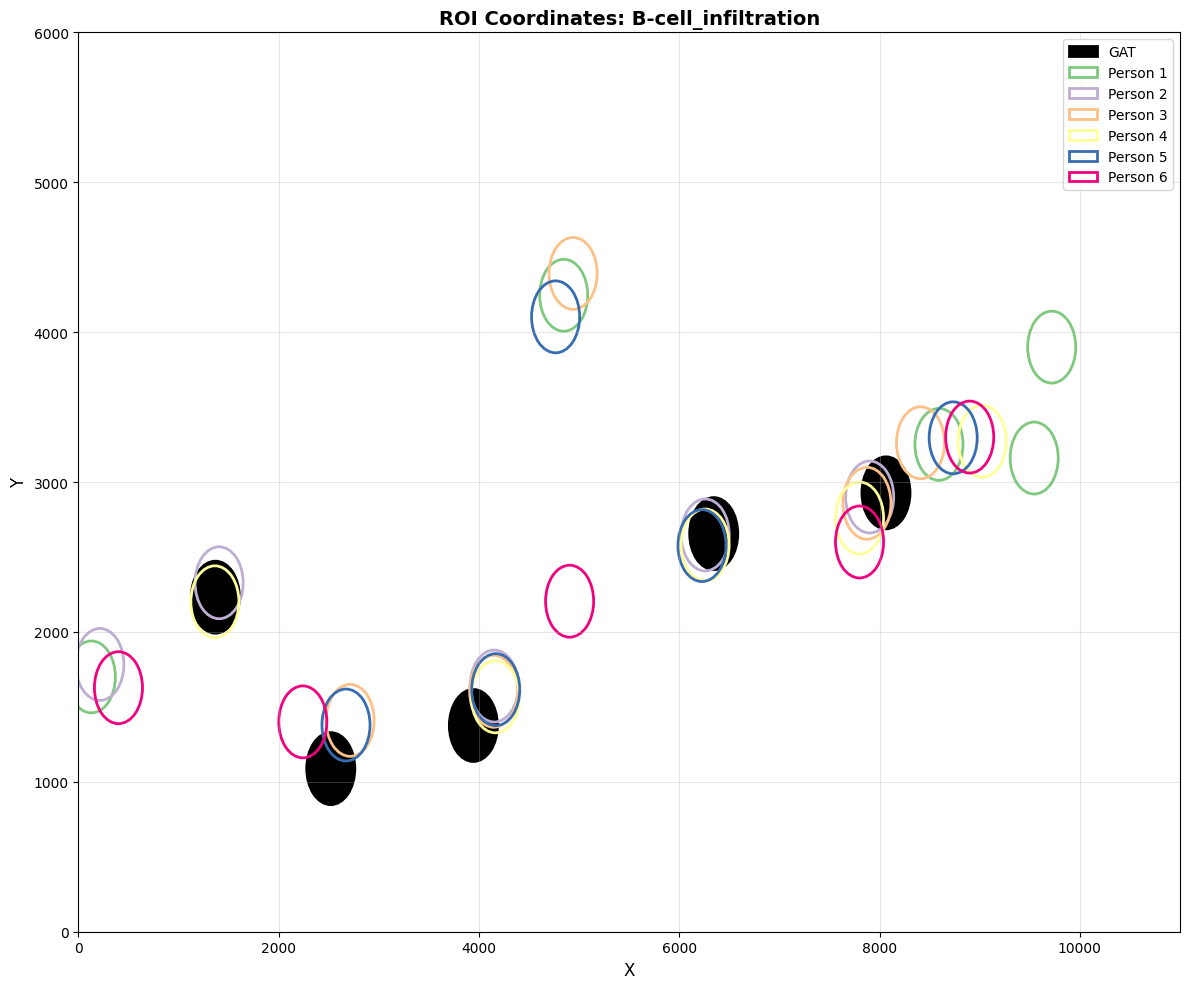


Processing: Inflammatory_zone
  Total rows: 35
  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_plot_Inflammatory_zone.png


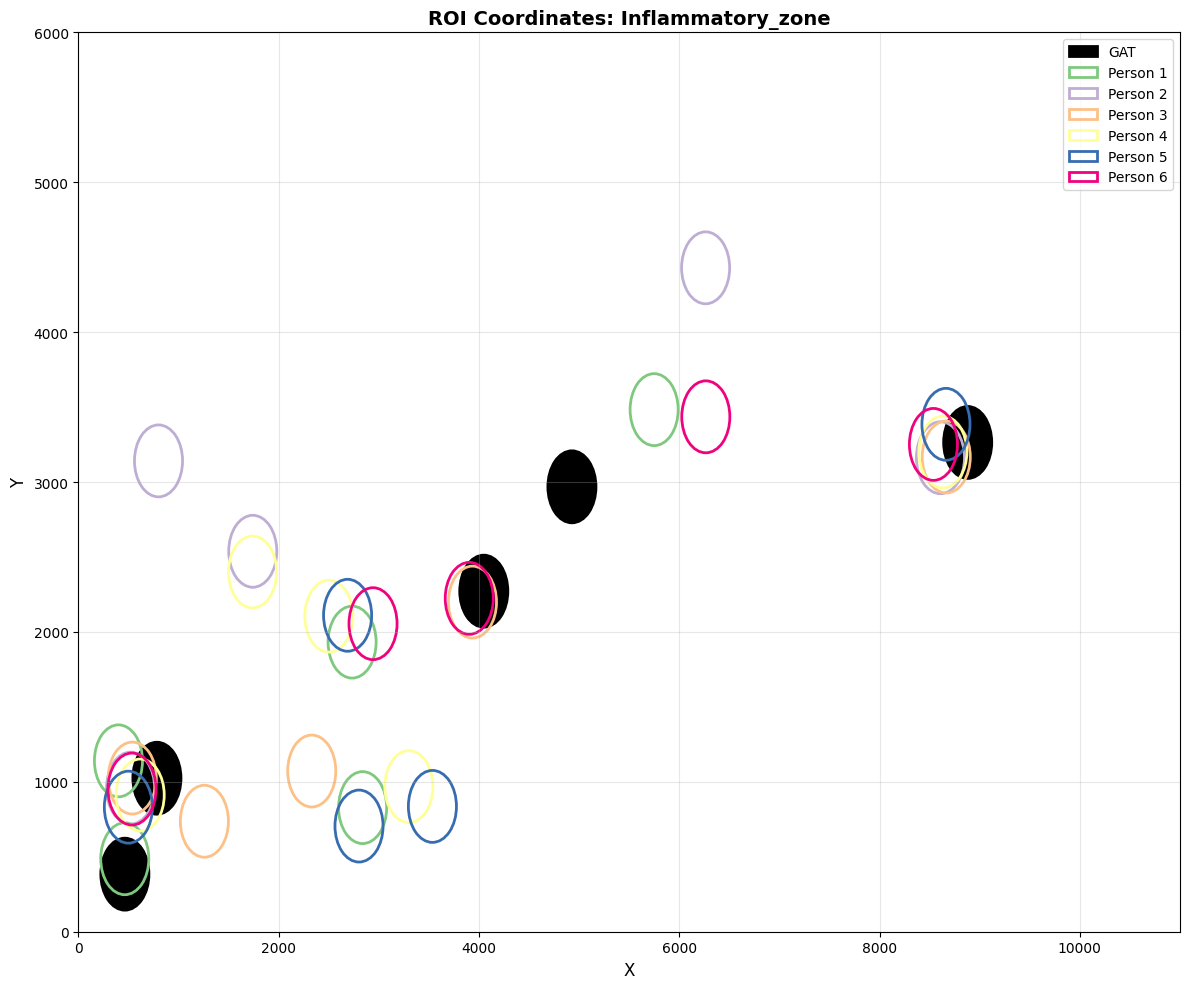


Processing: Oxidative_stress_regulation
  Total rows: 35
  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_plot_Oxidative_stress_regulation.png


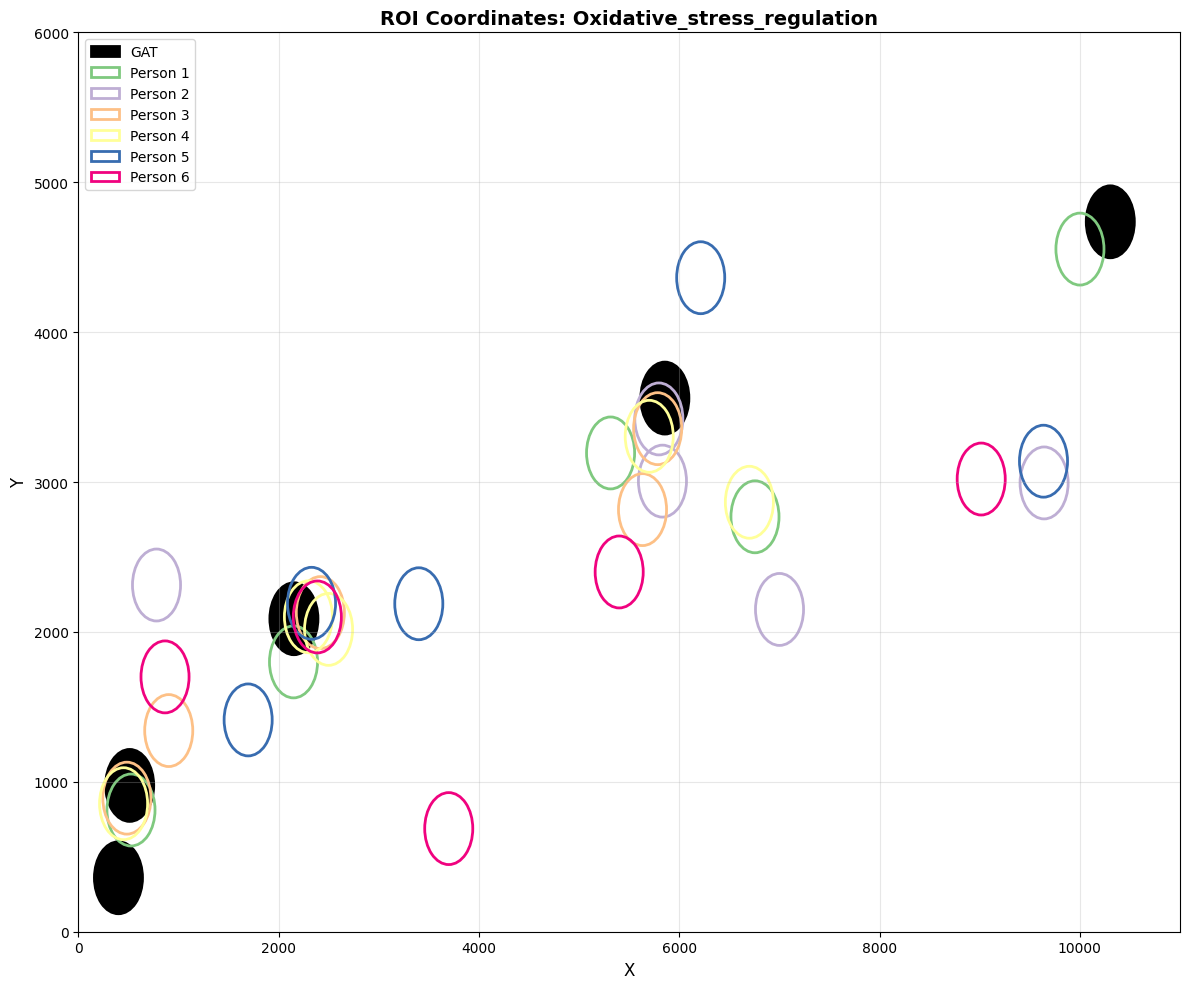


Processing: T-cell_maturation
  Total rows: 35
  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_plot_T-cell_maturation.png


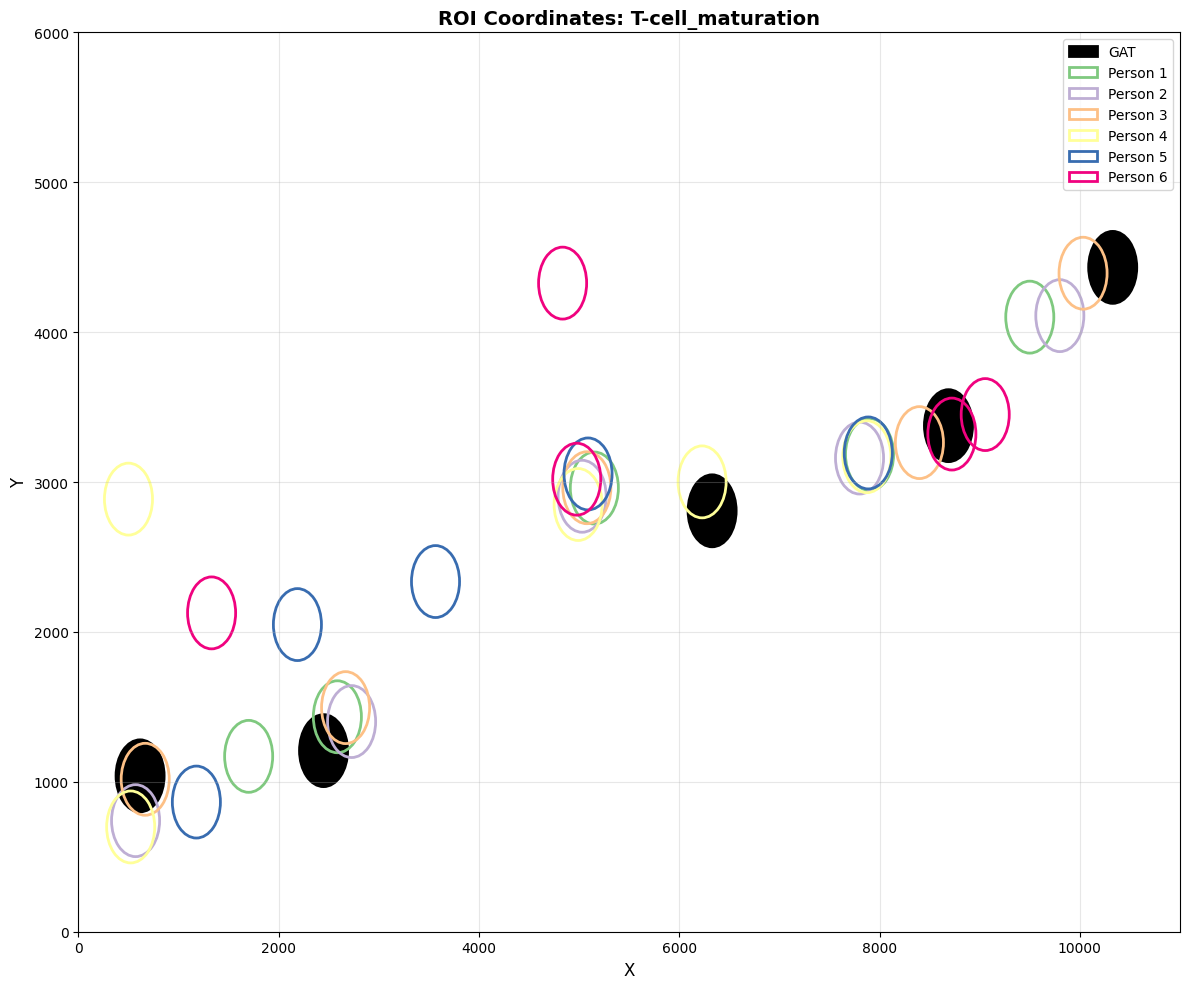


✓ All plots created successfully!


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from pathlib import Path
import numpy as np

# Define file paths
base_dir = Path(r"D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth")
csv_files = [
    'roi_coordinates_B-cell_infiltration.csv',
    'roi_coordinates_Inflammatory_zone.csv',
    'roi_coordinates_Oxidative_stress_regulation.csv',
    'roi_coordinates_T-cell_maturation.csv'
]

# Color palette
colors = {
    'GAT': '#000000',           # Black (filled)
    'Person 1': '#7fc97f',      # Green
    'Person 2': '#beaed4',      # Purple
    'Person 3': '#fdc086',      # Orange
    'Person 4': '#ffff99',      # Yellow
    'Person 5': '#386cb0',      # Blue
    'Person 6': '#f0027f'       # Pink
}

# Circle parameters
circle_radius = 240
stroke_width = 2

# Process each CSV file
for csv_filename in csv_files:
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        print(f"Warning: CSV file not found: {csv_path}")
        continue
    
    # Read CSV file
    df = pd.read_csv(csv_path)
    
    # Extract sheet name from filename
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    
    print(f"\nProcessing: {sheet_name}")
    print(f"  Total rows: {len(df)}")
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Group data by identifier (first column) and plot
    identifiers = df.iloc[:, 0].unique()  # Get unique identifiers from first column
    
    for identifier in identifiers:
        # Get all rows for this identifier
        identifier_data = df[df.iloc[:, 0] == identifier]
        
        # Get color for this identifier
        if identifier in colors:
            color = colors[identifier]
        else:
            # Default color if not in palette
            color = '#808080'
            print(f"  Warning: No color defined for '{identifier}', using gray")
        
        # Determine if filled (GAT) or hollow (others)
        is_filled = (identifier == 'GAT')
        
        # Plot circles for each row
        for idx, row in identifier_data.iterrows():
            # Third column (index 2) is x, fourth column (index 3) is y
            x_val = row.iloc[2]  # x coordinate
            y_val = row.iloc[3]  # y coordinate
            
            # Check if valid
            if pd.notna(x_val) and pd.notna(y_val):
                try:
                    x_float = float(x_val)
                    y_float = float(y_val)
                    
                    if not (np.isnan(x_float) or np.isnan(y_float)):
                        # Create circle
                        if is_filled:
                            circle = Circle((x_float, y_float), circle_radius,
                                          fill=True, facecolor=color,
                                          edgecolor=color, linewidth=stroke_width,
                                          label=identifier if idx == identifier_data.index[0] else '')
                        else:
                            circle = Circle((x_float, y_float), circle_radius,
                                          fill=False, edgecolor=color,
                                          linewidth=stroke_width,
                                          label=identifier if idx == identifier_data.index[0] else '')
                        ax.add_patch(circle)
                except (ValueError, TypeError):
                    continue
    
    # Set axis limits
    ax.set_xlim(0, 11000)
    ax.set_ylim(0, 6000)
    
    # Set labels and title
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_title(f'ROI Coordinates: {sheet_name}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=10)
    
    # Save plot
    plt.tight_layout()
    output_path = base_dir / f'roi_plot_{sheet_name}.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {output_path}")
    plt.show()

print(f"\n✓ All plots created successfully!")
